## Exploration with litemind for a structured query for regulatory programs

- last updated: 7/17/2025

- DESCRIBE the goals here:
    - preprocess the structured input from the peak UMAP clusters for LLM queries (this should be scripted in the future)
    
NOTE that this is an iterative process with the prompting.

EDIT (as of 7/17/2025):


In [1]:
# define the openAI API key
import os
# # Set the API key BEFORE importing and using litemind
# os.environ["OPENAI_API_KEY"] = ""
# For OpenAI
openai_api_key = os.environ.get('OPENAI_API_KEY')
print(f"OpenAI API key available: {'Yes' if openai_api_key else 'No'}")

OpenAI API key available: Yes


## Step 1. preprocess the structured input from the peak UMAP object
- scanpy/pandas to import and process the dataframe objects

### processing will be done in the following steps:
- First, import the peaks-by-pseudobulk matrix (with leiden clusters in adata.obs["leiden"]
- 1) context: a text blurb describing the data structure
Then, for each peak cluster, compute the following dataframes:
- 2) compute a vector for pseudobulk (averaging over peaks from each leiden cluster): a vector whose dimension is the celltype&timepoint
- 3) compute genes-by-counts (genes associated with each peak)
- 4) compute cluster-by-motif enrichment scores (computed by gimmemotifs maelstrom)



In [1]:
import scanpy as sc
import pandas as pd
import scipy
import numpy as np

In [2]:
adata_peaks = sc.read_h5ad("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/objects_v2/peaks_by_pb_annotated_master.h5ad")
adata_peaks

AnnData object with n_obs × n_vars = 640830 × 190
    obs: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'accessibility_neural_optic', 'accessibility_endoderm', 'accessibility_enteric_neurons', 'accessibility_notochord', 'accessibility_pharyngeal_arches', 'accessibility_floor_plate', 'accessibility_epidermis', 'accessibility_pronephros', 'accessibility_neural_floor_plate', 'accessibility_lateral_plate_mesoderm', 'accessibility_midbrain_hindbrain_boundary', 'accessibility_neural', 'accessibility_neurons', 'accessibility_neural_posterior', 'accessibility_neural_crest', 'accessibility_PSM', 'accessibility_fast_muscle', 'accessibility_endocrine_pancreas', 'accessibility_heart_myocardium', 'accessibility_neural_telencephalon', 'accessibility_optic_cup', 'accessibility_primordial_germ_cells', 'accessibility_differentiating_neurons', 'accessibility_muscle', 'accessibility_tail_bud', 'accessibility_hindbrain', 'accessibility_somites', 'accessibility_spinal_cord',

In [3]:
adata_peaks_ct_tp = sc.read_h5ad("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/objects_v2/peaks_by_ct_tp_master_anno.h5ad")
adata_peaks_ct_tp

AnnData object with n_obs × n_vars = 640830 × 190
    obs: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'accessibility_neural_optic', 'accessibility_endoderm', 'accessibility_enteric_neurons', 'accessibility_notochord', 'accessibility_pharyngeal_arches', 'accessibility_floor_plate', 'accessibility_epidermis', 'accessibility_pronephros', 'accessibility_neural_floor_plate', 'accessibility_lateral_plate_mesoderm', 'accessibility_midbrain_hindbrain_boundary', 'accessibility_neural', 'accessibility_neurons', 'accessibility_neural_posterior', 'accessibility_neural_crest', 'accessibility_PSM', 'accessibility_fast_muscle', 'accessibility_endocrine_pancreas', 'accessibility_heart_myocardium', 'accessibility_neural_telencephalon', 'accessibility_optic_cup', 'accessibility_primordial_germ_cells', 'accessibility_differentiating_neurons', 'accessibility_muscle', 'accessibility_tail_bud', 'accessibility_hindbrain', 'accessibility_somites', 'accessibility_spinal_cord',

In [4]:
# transfer the "leiden_unified" label (fine clustering)
adata_peaks_ct_tp.obs["leiden_unified"] = adata_peaks.obs["leiden_unified"]


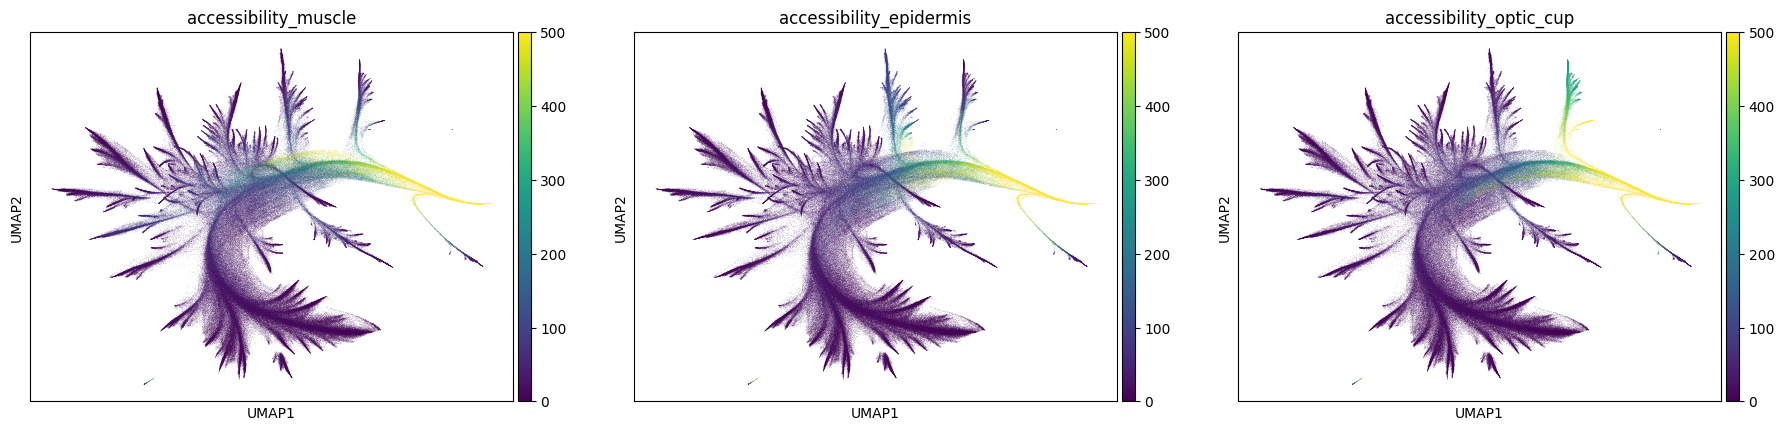

In [19]:
# sanity check
sc.pl.umap(adata_peaks_ct_tp, color=["accessibility_muscle","accessibility_epidermis",
                               "accessibility_optic_cup"], 
           vmin=0, vmax=500)

## Data Preprocessing for litemind (LLM) prompting

### 1) create a pseudobulk vector for each leiden cluster ("leiden_coarse")

In [8]:
# convert the counts layer to "normalized"
adata_peaks_ct_tp.X = adata_peaks_ct_tp.layers["normalized"].copy()

# Get the list of unique leiden clusters
leiden_clusters = adata_peaks_ct_tp.obs["leiden_coarse"].unique()

# Create a pandas DataFrame to store the results
cluster_pseudobulk_df = pd.DataFrame(
    index=leiden_clusters,
    columns=adata_peaks_ct_tp.var_names
)

# Option 1: Using pandas groupby for vectorized operations
# This is often more memory-efficient for large datasets
pseudobulk_matrix = pd.DataFrame(
    adata_peaks_ct_tp.X.toarray() if scipy.sparse.issparse(adata_peaks_ct_tp.X) else adata_peaks_ct_tp.X,
    index=adata_peaks_ct_tp.obs["leiden_coarse"],
    columns=adata_peaks_ct_tp.var_names
)
cluster_pseudobulk_df = pseudobulk_matrix.groupby(level=0).mean()

cluster_pseudobulk_df.head()

/tmp/ipykernel_366503/1769901802.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_pseudobulk_df = pseudobulk_matrix.groupby(level=0).mean()


,NMPs_0somites,NMPs_5somites,NMPs_10somites,NMPs_15somites,NMPs_20somites,NMPs_30somites,PSM_0somites,PSM_5somites,PSM_10somites,PSM_15somites,...,spinal_cord_10somites,spinal_cord_15somites,spinal_cord_20somites,spinal_cord_30somites,tail_bud_0somites,tail_bud_5somites,tail_bud_10somites,tail_bud_15somites,tail_bud_20somites,tail_bud_30somites
leiden_coarse,,,,,,,,,,,,,,,,,,,,,
0,1.444744,1.736972,1.600943,1.643772,1.577514,0.206095,1.462885,1.607744,1.403402,1.558934,...,1.608511,1.757049,1.586428,2.127775,1.449017,1.704275,1.502976,1.569951,1.685060,0.000000
1,2.131835,2.461514,2.244404,2.270387,2.147832,0.338841,2.038396,2.318044,2.106641,2.092025,...,2.003685,2.009821,1.882617,2.258033,2.100600,2.426102,2.218865,2.221107,2.108461,0.000000
2,4.429297,4.895520,4.533454,4.670540,4.516309,1.382703,4.216470,4.636306,4.276274,4.325705,...,4.289830,4.343214,4.182990,4.420302,4.322889,4.811980,4.418954,4.434719,4.340978,0.893212
3,6.006532,6.413821,6.262182,7.543516,6.808346,6.924028,5.061176,5.765861,5.185030,6.562312,...,8.422177,9.987636,10.302850,12.285037,5.250215,5.941834,5.385656,6.294444,6.665793,12.777163
4,1.539328,1.776131,1.645937,1.869491,1.573531,0.253594,1.479987,1.680020,1.506178,1.698154,...,1.476089,1.675879,1.408144,1.814087,1.526767,1.792698,1.568935,1.790604,1.491195,0.000000


In [9]:
# save the count matrix as csv file
cluster_pseudobulk_df.to_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/objects_v2/leiden_by_pseudobulk.csv")

### 1-2) create a pseudobulk vector for each leiden cluster ("leiden_unified") - fine clusters 

In [6]:
# convert the counts layer to "normalized"
adata_peaks_ct_tp.X = adata_peaks_ct_tp.layers["normalized"].copy()

# Get the list of unique leiden clusters
leiden_clusters = adata_peaks_ct_tp.obs["leiden_unified"].unique()

# Create a pandas DataFrame to store the results
cluster_pseudobulk_df = pd.DataFrame(
    index=leiden_clusters,
    columns=adata_peaks_ct_tp.var_names
)

# Option 1: Using pandas groupby for vectorized operations
# This is often more memory-efficient for large datasets
pseudobulk_matrix = pd.DataFrame(
    adata_peaks_ct_tp.X.toarray() if scipy.sparse.issparse(adata_peaks_ct_tp.X) else adata_peaks_ct_tp.X,
    index=adata_peaks_ct_tp.obs["leiden_unified"],
    columns=adata_peaks_ct_tp.var_names
)
cluster_pseudobulk_df = pseudobulk_matrix.groupby(level=0).mean()

cluster_pseudobulk_df.head()

/tmp/ipykernel_606654/1816116587.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_pseudobulk_df = pseudobulk_matrix.groupby(level=0).mean()


,NMPs_0somites,NMPs_5somites,NMPs_10somites,NMPs_15somites,NMPs_20somites,NMPs_30somites,PSM_0somites,PSM_5somites,PSM_10somites,PSM_15somites,...,spinal_cord_10somites,spinal_cord_15somites,spinal_cord_20somites,spinal_cord_30somites,tail_bud_0somites,tail_bud_5somites,tail_bud_10somites,tail_bud_15somites,tail_bud_20somites,tail_bud_30somites
leiden_unified,,,,,,,,,,,,,,,,,,,,,
0_0,1.108031,1.377118,1.231364,1.206174,1.100142,0.000000,1.114527,1.243043,1.096017,1.179734,...,1.175615,1.248453,1.113090,1.306547,1.116641,1.253342,1.148106,1.229772,1.116169,0.0
0_1,1.924470,2.249666,2.127493,2.267231,2.257641,0.499724,1.959202,2.127346,1.841342,2.099191,...,2.225272,2.481661,2.260807,3.297804,1.922564,2.346733,2.008571,2.054614,2.495576,0.0
1_0,1.192102,1.445631,1.214746,1.279689,1.197213,0.324617,1.134980,1.312871,1.173320,1.207305,...,1.139096,1.163669,1.080010,1.455522,1.193292,1.389306,1.228024,1.302364,1.146367,0.0
1_1,1.062062,1.205928,1.117342,1.191578,1.102641,0.387448,0.993535,1.144907,1.027687,1.022095,...,0.946267,1.003604,0.909412,1.195133,1.022150,1.198623,1.083203,1.095873,1.056248,0.0
1_2,1.605334,1.911532,1.816178,2.665577,1.701685,0.282949,1.460828,1.686941,1.571546,2.449741,...,1.647059,2.501530,1.567930,1.873756,1.576623,1.815950,1.704958,2.577673,1.640352,0.0


In [17]:
cluster_pseudobulk_df.to_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/objects_v2/leiden_unified_by_pseudobulk.csv")

### EDIT (7/17/2025)
- we wanted to add "std" as well as "mean" to account for the variability



In [12]:
import pandas as pd
import numpy as np
import scipy.sparse

# Convert the counts layer to "normalized"
adata_peaks_ct_tp.X = adata_peaks_ct_tp.layers["normalized"].copy()

# Get the list of unique leiden clusters
leiden_clusters = adata_peaks_ct_tp.obs["leiden_coarse"].unique()

# Create the pseudobulk matrix for vectorized operations
pseudobulk_matrix = pd.DataFrame(
    adata_peaks_ct_tp.X.toarray() if scipy.sparse.issparse(adata_peaks_ct_tp.X) else adata_peaks_ct_tp.X,
    index=adata_peaks_ct_tp.obs["leiden_coarse"],
    columns=adata_peaks_ct_tp.var_names
)

# Compute both mean and std using groupby
print("Computing mean and std accessibility per cluster...")
cluster_pseudobulk_mean = pseudobulk_matrix.groupby(level=0).mean()
cluster_pseudobulk_std = pseudobulk_matrix.groupby(level=0).std()
# Compute count (number of peaks per cluster) for SEM calculation
cluster_pseudobulk_count = pseudobulk_matrix.groupby(level=0).count()

# Calculate Standard Error of the Mean (SEM = std / sqrt(n))
cluster_pseudobulk_sem = cluster_pseudobulk_std / np.sqrt(cluster_pseudobulk_count)

print(f"✓ Computed statistics for {len(leiden_clusters)} clusters across {len(adata_peaks_ct_tp.var_names)} pseudobulk profiles")

# Add proper column naming to differentiate mean and std
# Method 1: Add suffixes to column names
cluster_pseudobulk_mean_renamed = cluster_pseudobulk_mean.add_suffix('_mean')
cluster_pseudobulk_std_renamed = cluster_pseudobulk_std.add_suffix('_std')
cluster_pseudobulk_sem_renamed = cluster_pseudobulk_sem.add_suffix('_sem')
cluster_pseudobulk_n_peaks_renamed = cluster_pseudobulk_count.add_suffix('_n_peaks')


# Method 2: Alternative - more descriptive naming based on celltype_timepoint pattern
# If your var_names follow a pattern like "celltype_timepoint", you can use:
# cluster_pseudobulk_mean_renamed = cluster_pseudobulk_mean.add_suffix('_mean')
# cluster_pseudobulk_std_renamed = cluster_pseudobulk_std.add_suffix('_std')

# Concatenate mean and std DataFrames horizontally
cluster_pseudobulk_combined = pd.concat([
    cluster_pseudobulk_mean_renamed, 
    cluster_pseudobulk_sem_renamed
], axis=1)

print(f"✓ Combined dataframe shape: {cluster_pseudobulk_combined.shape}")
print(f"✓ Columns: {cluster_pseudobulk_combined.shape[1]} total ({cluster_pseudobulk_combined.shape[1]//2} mean + {cluster_pseudobulk_combined.shape[1]//2} sem)")


# Optional: Sort columns to group mean and std together for each pseudobulk profile
# This will interleave mean and std for each pseudobulk profile
def sort_columns_interleaved(df):
    """Sort columns so mean and std for each pseudobulk profile are together"""
    
    # Extract base names (without _mean/_std suffix)
    base_names = []
    for col in df.columns:
        if col.endswith('_mean'):
            base_names.append(col[:-5])  # Remove '_mean'
        elif col.endswith('_sem'):
            base_names.append(col[:-4])   # Remove '_sem'
    
    # Get unique base names
    unique_base_names = sorted(set(base_names))
    
    # Create new column order: base_name_mean, base_name_std, ...
    new_column_order = []
    for base_name in unique_base_names:
        if f"{base_name}_mean" in df.columns:
            new_column_order.append(f"{base_name}_mean")
        if f"{base_name}_sem" in df.columns:
            new_column_order.append(f"{base_name}_sem")
    
    return df[new_column_order]

# Apply interleaved sorting (optional)
print("\nApplying interleaved column sorting...")
cluster_pseudobulk_final = sort_columns_interleaved(cluster_pseudobulk_combined)

# Display the results
print("\nFirst few rows and columns of the combined dataframe:")
print(cluster_pseudobulk_final.iloc[:5, :10])  # First 5 rows, first 10 columns

print("Column order after interleaving (first 10 columns):")
print(cluster_pseudobulk_final.columns[:10].tolist())

# Alternative: Keep original order (mean columns first, then std columns)
# cluster_pseudobulk_final = cluster_pseudobulk_combined

# Save to CSV
output_path = "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/objects_v2/"
output_filename = 'leiden_coarse_by_pseudobulk_mean_sem.csv'
cluster_pseudobulk_final.to_csv(output_path + output_filename)
print(f"\n✓ Saved combined mean and sem data to '{output_filename}'")

Computing mean and std accessibility per cluster...


/tmp/ipykernel_2156408/3229036155.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_pseudobulk_mean = pseudobulk_matrix.groupby(level=0).mean()
/tmp/ipykernel_2156408/3229036155.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_pseudobulk_std = pseudobulk_matrix.groupby(level=0).std()
/tmp/ipykernel_2156408/3229036155.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_pseudobulk_count = ps

✓ Computed statistics for 36 clusters across 190 pseudobulk profiles
✓ Combined dataframe shape: (36, 380)
✓ Columns: 380 total (190 mean + 190 sem)

Applying interleaved column sorting...

First few rows and columns of the combined dataframe:
               NMPs_0somites_mean  NMPs_0somites_sem  NMPs_10somites_mean  \
leiden_coarse                                                               
0                        1.444744           0.067175             1.600943   
1                        2.131835           0.006894             2.244404   
2                        4.429297           0.029144             4.533454   
3                        6.006532           0.073418             6.262182   
4                        1.539328           0.015036             1.645937   

               NMPs_10somites_sem  NMPs_15somites_mean  NMPs_15somites_sem  \
leiden_coarse                                                                
0                        0.084492             1.643772      

In [13]:
import pandas as pd
import numpy as np
import scipy.sparse

# Convert the counts layer to "normalized"
adata_peaks_ct_tp.X = adata_peaks_ct_tp.layers["normalized"].copy()

# Get the list of unique leiden clusters
leiden_clusters = adata_peaks_ct_tp.obs["leiden_unified"].unique()

# Create the pseudobulk matrix for vectorized operations
pseudobulk_matrix = pd.DataFrame(
    adata_peaks_ct_tp.X.toarray() if scipy.sparse.issparse(adata_peaks_ct_tp.X) else adata_peaks_ct_tp.X,
    index=adata_peaks_ct_tp.obs["leiden_unified"],
    columns=adata_peaks_ct_tp.var_names
)

# Compute both mean and std using groupby
print("Computing mean and std accessibility per cluster...")
cluster_pseudobulk_mean = pseudobulk_matrix.groupby(level=0).mean()
cluster_pseudobulk_std = pseudobulk_matrix.groupby(level=0).std()
# Compute count (number of peaks per cluster) for SEM calculation
cluster_pseudobulk_count = pseudobulk_matrix.groupby(level=0).count()

# Calculate Standard Error of the Mean (SEM = std / sqrt(n))
cluster_pseudobulk_sem = cluster_pseudobulk_std / np.sqrt(cluster_pseudobulk_count)

print(f"✓ Computed statistics for {len(leiden_clusters)} clusters across {len(adata_peaks_ct_tp.var_names)} pseudobulk profiles")

# Add proper column naming to differentiate mean and std
# Method 1: Add suffixes to column names
cluster_pseudobulk_mean_renamed = cluster_pseudobulk_mean.add_suffix('_mean')
cluster_pseudobulk_std_renamed = cluster_pseudobulk_std.add_suffix('_std')
cluster_pseudobulk_sem_renamed = cluster_pseudobulk_sem.add_suffix('_sem')
cluster_pseudobulk_n_peaks_renamed = cluster_pseudobulk_count.add_suffix('_n_peaks')


# Method 2: Alternative - more descriptive naming based on celltype_timepoint pattern
# If your var_names follow a pattern like "celltype_timepoint", you can use:
# cluster_pseudobulk_mean_renamed = cluster_pseudobulk_mean.add_suffix('_mean')
# cluster_pseudobulk_std_renamed = cluster_pseudobulk_std.add_suffix('_std')

# Concatenate mean and std DataFrames horizontally
cluster_pseudobulk_combined = pd.concat([
    cluster_pseudobulk_mean_renamed, 
    cluster_pseudobulk_sem_renamed
], axis=1)

print(f"✓ Combined dataframe shape: {cluster_pseudobulk_combined.shape}")
print(f"✓ Columns: {cluster_pseudobulk_combined.shape[1]} total ({cluster_pseudobulk_combined.shape[1]//2} mean + {cluster_pseudobulk_combined.shape[1]//2} sem)")


# Apply interleaved sorting (optional)
print("\nApplying interleaved column sorting...")
cluster_pseudobulk_final = sort_columns_interleaved(cluster_pseudobulk_combined)

# Display the results
print("\nFirst few rows and columns of the combined dataframe:")
print(cluster_pseudobulk_final.iloc[:5, :10])  # First 5 rows, first 10 columns

print("Column order after interleaving (first 10 columns):")
print(cluster_pseudobulk_final.columns[:10].tolist())

# Alternative: Keep original order (mean columns first, then std columns)
# cluster_pseudobulk_final = cluster_pseudobulk_combined

# Save to CSV
output_path = "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/objects_v2/"
output_filename = 'leiden_fine_by_pseudobulk_mean_sem.csv'
cluster_pseudobulk_final.to_csv(output_path + output_filename)
print(f"\n✓ Saved combined mean and sem data to '{output_filename}'")

Computing mean and std accessibility per cluster...


/tmp/ipykernel_2156408/1402587257.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_pseudobulk_mean = pseudobulk_matrix.groupby(level=0).mean()
/tmp/ipykernel_2156408/1402587257.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_pseudobulk_std = pseudobulk_matrix.groupby(level=0).std()
/tmp/ipykernel_2156408/1402587257.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_pseudobulk_count = ps

✓ Computed statistics for 402 clusters across 190 pseudobulk profiles
✓ Combined dataframe shape: (402, 380)
✓ Columns: 380 total (190 mean + 190 sem)

Applying interleaved column sorting...

First few rows and columns of the combined dataframe:
                NMPs_0somites_mean  NMPs_0somites_sem  NMPs_10somites_mean  \
leiden_unified                                                               
0_0                       1.108031           0.058838             1.231364   
0_1                       1.924470           0.132133             2.127493   
1_0                       1.192102           0.022102             1.214746   
1_1                       1.062062           0.014177             1.117342   
1_2                       1.605334           0.050856             1.816178   

                NMPs_10somites_sem  NMPs_15somites_mean  NMPs_15somites_sem  \
leiden_unified                                                                
0_0                       0.077709             1.

In [9]:
cluster_pseudobulk_final.head()

,NMPs_0somites_mean,NMPs_0somites_std,NMPs_10somites_mean,NMPs_10somites_std,NMPs_15somites_mean,NMPs_15somites_std,NMPs_20somites_mean,NMPs_20somites_std,NMPs_30somites_mean,NMPs_30somites_std,...,tail_bud_10somites_mean,tail_bud_10somites_std,tail_bud_15somites_mean,tail_bud_15somites_std,tail_bud_20somites_mean,tail_bud_20somites_std,tail_bud_30somites_mean,tail_bud_30somites_std,tail_bud_5somites_mean,tail_bud_5somites_std
leiden_coarse,,,,,,,,,,,,,,,,,,,,,
0,1.444744,1.426581,1.600943,1.794334,1.643772,1.912322,1.577514,2.409216,0.206095,4.376785,...,1.502976,1.324534,1.569951,1.563872,1.685060,2.484726,0.000000,0.000000,1.704275,1.271296
1,2.131835,1.823272,2.244404,2.327087,2.270387,2.348355,2.147832,2.945248,0.338841,5.732592,...,2.218865,2.013141,2.221107,2.027337,2.108461,2.496045,0.000000,0.000000,2.426102,1.767273
2,4.429297,4.724988,4.533454,5.081683,4.670540,4.974170,4.516309,5.730252,1.382703,11.960304,...,4.418954,4.659491,4.434719,4.531007,4.340978,5.150020,0.893212,14.863528,4.811980,4.378922
3,6.006532,6.439043,6.262182,7.208685,7.543516,8.064601,6.808346,8.971662,6.924028,29.070471,...,5.385656,6.136311,6.294444,6.756583,6.665793,7.818773,12.777163,59.345904,5.941834,5.485860
4,1.539328,1.254748,1.645937,1.763704,1.869491,2.278842,1.573531,2.411596,0.253594,4.848739,...,1.568935,1.383475,1.790604,1.935929,1.491195,1.854748,0.000000,0.000000,1.792698,1.229047


### 2) create a dataframe of genes-by-counts for each leiden cluster - both coarse and fine
- coarse is "leiden_coarse"
- fine is "leiden_unified"

In [16]:
adata_peaks_ct_tp

AnnData object with n_obs × n_vars = 640830 × 190
    obs: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'accessibility_neural_optic', 'accessibility_endoderm', 'accessibility_enteric_neurons', 'accessibility_notochord', 'accessibility_pharyngeal_arches', 'accessibility_floor_plate', 'accessibility_epidermis', 'accessibility_pronephros', 'accessibility_neural_floor_plate', 'accessibility_lateral_plate_mesoderm', 'accessibility_midbrain_hindbrain_boundary', 'accessibility_neural', 'accessibility_neurons', 'accessibility_neural_posterior', 'accessibility_neural_crest', 'accessibility_PSM', 'accessibility_fast_muscle', 'accessibility_endocrine_pancreas', 'accessibility_heart_myocardium', 'accessibility_neural_telencephalon', 'accessibility_optic_cup', 'accessibility_primordial_germ_cells', 'accessibility_differentiating_neurons', 'accessibility_muscle', 'accessibility_tail_bud', 'accessibility_hindbrain', 'accessibility_somites', 'accessibility_spinal_cord',

In [18]:
adata_peaks_ct_tp.obs["association_type"].unique()

['none', 'overlap', 'linked']
Categories (3, object): ['linked', 'none', 'overlap']

In [11]:
# import the annotation ("associated_genes")
df_genes_anno = pd.read_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/objects_v2/all_peaks_annotated.csv",
                            index_col=0)
df_genes_anno.head()

,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,accessibility_neural_optic,accessibility_endoderm,accessibility_enteric_neurons,accessibility_notochord,accessibility_pharyngeal_arches,accessibility_floor_plate,...,is_linked,chrom,start,end,peak_type,length,gene_body_overlaps,nearest_gene,distance_to_tss,leiden_coarse
1-32-526,131,2.694737,31.052632,512.0,15.613128,10.325988,6.689899,2.991895,12.762588,12.170900,...,Not linked,1,32,526,intergenic,494,NaN,cep97,11542.0,7
1-2372-3057,162,8.294737,14.736842,1576.0,57.789060,19.729371,42.719110,17.231317,22.624311,36.413397,...,Not linked,1,2372,3057,intergenic,685,NaN,cep97,9107.0,12
1-3427-4032,170,18.636842,10.526316,3541.0,94.465606,30.845398,105.145162,41.163118,72.624480,72.500155,...,Not linked,1,3427,4032,intergenic,605,NaN,cep97,8092.0,33
1-4469-7268,190,160.247368,0.000000,30447.0,568.299814,493.321985,480.077318,535.338964,641.692987,543.858841,...,Not linked,1,4469,7268,exonic,2799,rpl24,cep97,5953.0,26
1-9541-9969,172,33.905263,9.473684,6442.0,118.378152,102.449880,65.013071,141.397103,178.130543,108.393402,...,Not linked,1,9541,9969,promoter,428,rpl24,cep97,2066.0,33


In [12]:
# copy over the metadata ("linked_gene", etc.)
metadata_list = ['linked_gene', 'link_score', 'link_zscore', 'link_pvalue']
for col in metadata_list:
    adata_peaks_ct_tp.obs[col] = adata_peaks_ct_tp.obs_names.map(df_genes_anno[col])

adata_peaks_ct_tp.obs["linked_gene"]


1-32-526                NaN
1-2372-3057             NaN
1-3427-4032             NaN
1-4469-7268             NaN
1-9541-9969             NaN
                       ... 
25-37496420-37496948    NaN
25-37497049-37497789    NaN
25-37498106-37500090    NaN
25-37500598-37500859    NaN
25-37501104-37501839    NaN
Name: linked_gene, Length: 640830, dtype: object

In [13]:
# import the functions to annotate the peaks with "associated genes"
# this function uses "linked_genes" from Signac and "overlapping with gene body" based on GTF file
from utils_gene_annotate import *

In [14]:
# associate peaks to genes
# (1) use "linked_gene" if possible
# (2) use "gene_body_overlaps" as secondary
# (3) add NaN otherwise
adata_peaks_ct_tp = create_gene_associations(adata_peaks_ct_tp)
adata_peaks_ct_tp.obs.head()

,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,accessibility_neural_optic,accessibility_endoderm,accessibility_enteric_neurons,accessibility_notochord,accessibility_pharyngeal_arches,accessibility_floor_plate,...,gene_body_overlaps,nearest_gene,distance_to_tss,leiden_coarse,linked_gene,link_score,link_zscore,link_pvalue,associated_gene,association_type
1-32-526,131,2.694737,31.052632,512.0,15.613128,10.325988,6.689899,2.991895,12.762588,12.170900,...,,cep97,11542.0,7,NaN,NaN,NaN,NaN,None,none
1-2372-3057,162,8.294737,14.736842,1576.0,57.789060,19.729371,42.719110,17.231317,22.624311,36.413397,...,,cep97,9107.0,12,NaN,NaN,NaN,NaN,None,none
1-3427-4032,170,18.636842,10.526316,3541.0,94.465606,30.845398,105.145162,41.163118,72.624480,72.500155,...,,cep97,8092.0,33,NaN,NaN,NaN,NaN,None,none
1-4469-7268,190,160.247368,0.000000,30447.0,568.299814,493.321985,480.077318,535.338964,641.692987,543.858841,...,rpl24,cep97,5953.0,26,NaN,NaN,NaN,NaN,rpl24,overlap
1-9541-9969,172,33.905263,9.473684,6442.0,118.378152,102.449880,65.013071,141.397103,178.130543,108.393402,...,rpl24,cep97,2066.0,33,NaN,NaN,NaN,NaN,rpl24,overlap


In [15]:
adata_peaks_ct_tp.obs["associated_gene"]

1-32-526                          None
1-2372-3057                       None
1-3427-4032                       None
1-4469-7268                      rpl24
1-9541-9969                      rpl24
                             ...      
25-37496420-37496948    CABZ01088346.1
25-37497049-37497789    CABZ01088346.1
25-37498106-37500090    CABZ01088346.1
25-37500598-37500859    CABZ01088346.1
25-37501104-37501839    CABZ01088346.1
Name: associated_gene, Length: 640830, dtype: object

In [19]:
# Some genes might have multiple entries, so we'll create a function to handle this
def process_gene_entries(gene_entry):
    if pd.isna(gene_entry):
        return []
    # Handle different possible formats of gene entries (comma-separated, list, etc.)
    if isinstance(gene_entry, str):
        return [g.strip() for g in gene_entry.split(',') if g.strip()]
    return [gene_entry]

In [16]:
# First, let's extract the relevant columns from adata_peaks_ct_tp.obs
peak_gene_data = adata_peaks_ct_tp.obs[["leiden_coarse", "associated_gene"]].copy()

# Create an expanded DataFrame with one row per peak-gene pair
peak_gene_pairs = []
for idx, row in peak_gene_data.iterrows():
    genes = process_gene_entries(row["associated_gene"])
    for gene in genes:
        peak_gene_pairs.append({
            "leiden": row["leiden_coarse"],
            "gene": gene
        })

# Convert to DataFrame
peak_gene_df = pd.DataFrame(peak_gene_pairs)

# If there are no valid gene associations, handle this case
if len(peak_gene_df) == 0:
    print("No gene associations found in the dataset")
    genes_by_counts = pd.DataFrame(index=adata_peaks_ct_tp.obs["leiden"].unique())
else:
    # Count occurrences of each gene in each leiden cluster
    gene_counts = peak_gene_df.groupby(["leiden", "gene"]).size().reset_index(name="count")
    
    # Pivot to create a leiden cluster x gene matrix
    genes_by_counts = gene_counts.pivot(index="leiden", columns="gene", values="count").fillna(0)
    
    # Ensure we have a row for every leiden cluster (even if no genes are associated)
    missing_clusters = set(adata_peaks_ct_tp.obs["leiden_coarse"].unique()) - set(genes_by_counts.index)
    for cluster in missing_clusters:
        genes_by_counts.loc[cluster] = 0
    
    # Sort the rows by leiden cluster
    genes_by_counts = genes_by_counts.loc[sorted(genes_by_counts.index)]

print(f"Created genes-by-counts matrix with shape: {genes_by_counts.shape}")

Created genes-by-counts matrix with shape: (36, 28125)


In [17]:
genes_by_counts.head()

gene,ABCA7,ABCC5,ACAP2,ACBD3,ACKR2,ACOT12,ACSF3,ACTC1,ACVR1C,ADAM12,...,zswim8,zte38,zufsp,zw10,zwi,zwilch,zyg11,zyx,zzef1,zzz3
leiden,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,3.0,1.0,3.0,2.0,0.0,0.0,4.0,0.0,5.0,4.0,...,1.0,1.0,1.0,0.0,0.0,0.0,4.0,2.0,7.0,2.0
2,0.0,0.0,3.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0,2.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [18]:
# First, create a dictionary that maps each leiden cluster to its associated genes
leiden_to_genes = {}

for leiden in genes_by_counts.index:
    # Get the genes that have counts > 0 for this leiden cluster
    genes_present = genes_by_counts.loc[leiden]
    genes_present = genes_present[genes_present > 0].index.tolist()
    
    # Store in dictionary
    leiden_to_genes[leiden] = genes_present

# If you need a DataFrame with comma-separated gene lists
leiden_gene_lists_df = pd.DataFrame({
    'leiden': list(leiden_to_genes.keys()),
    'genes': [','.join(genes) for genes in leiden_to_genes.values()]
})
leiden_gene_lists_df.set_index('leiden', inplace=True)

# Print example
print(leiden_gene_lists_df.head())

                                                    genes
leiden                                                   
0       AL929378.2,BX004800.1,BX004996.1,BX255912.1,BX...
1       ABCA7,ABCC5,ACAP2,ACBD3,ACSF3,ACVR1C,ADAM12,AD...
2       ACAP2,ACOT12,ADAMTS7,ADGRL2,ADGRL3,AK6,AL59014...
3       ADAMTS7,ADGRL3,AL590146.1,AL590149.1,AL590151....
4       ACVR1C,ADAMTS7,ADGRL2,AL590149.1,AL845324.1,AL...


In [41]:
genes_by_counts.to_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/objects_v2/leiden_by_assoc_genes.csv")

### 2-2) fine clusters: "leiden_unified"


In [20]:
# First, let's extract the relevant columns from adata_peaks_ct_tp.obs
peak_gene_data = adata_peaks_ct_tp.obs[["leiden_unified", "associated_gene"]].copy()

# Create an expanded DataFrame with one row per peak-gene pair
peak_gene_pairs = []
for idx, row in peak_gene_data.iterrows():
    genes = process_gene_entries(row["associated_gene"])
    for gene in genes:
        peak_gene_pairs.append({
            "leiden": row["leiden_unified"],
            "gene": gene
        })

# Convert to DataFrame
peak_gene_df = pd.DataFrame(peak_gene_pairs)

# If there are no valid gene associations, handle this case
if len(peak_gene_df) == 0:
    print("No gene associations found in the dataset")
    genes_by_counts = pd.DataFrame(index=adata_peaks_ct_tp.obs["leiden"].unique())
else:
    # Count occurrences of each gene in each leiden cluster
    gene_counts = peak_gene_df.groupby(["leiden", "gene"]).size().reset_index(name="count")
    
    # Pivot to create a leiden cluster x gene matrix
    genes_by_counts = gene_counts.pivot(index="leiden", columns="gene", values="count").fillna(0)
    
    # Ensure we have a row for every leiden cluster (even if no genes are associated)
    missing_clusters = set(adata_peaks_ct_tp.obs["leiden_unified"].unique()) - set(genes_by_counts.index)
    for cluster in missing_clusters:
        genes_by_counts.loc[cluster] = 0
    
    # Sort the rows by leiden cluster
    genes_by_counts = genes_by_counts.loc[sorted(genes_by_counts.index)]

print(f"Created genes-by-counts matrix with shape: {genes_by_counts.shape}")

Created genes-by-counts matrix with shape: (402, 28125)


In [21]:
# sanity check
leiden_to_genes = {}

for leiden in genes_by_counts.index:
    # Get the genes that have counts > 0 for this leiden cluster
    genes_present = genes_by_counts.loc[leiden]
    genes_present = genes_present[genes_present > 0].index.tolist()
    
    # Store in dictionary
    leiden_to_genes[leiden] = genes_present

# If you need a DataFrame with comma-separated gene lists
leiden_gene_lists_df = pd.DataFrame({
    'leiden': list(leiden_to_genes.keys()),
    'genes': [','.join(genes) for genes in leiden_to_genes.values()]
})
leiden_gene_lists_df.set_index('leiden', inplace=True)

# Print example
print(leiden_gene_lists_df.head())

                                                    genes
leiden                                                   
0_0     AL929378.2,BX004996.1,BX284620.3,BX510919.1,BX...
0_1     AL929378.2,BX004800.1,BX255912.1,CACNA2D3,CR79...
10_0    ADAM12,AL929208.1,AL929210.1,AL929378.2,BRSK2,...
10_1    ABCC5,ADAMTS7,AL805905.2,AL928866.2,AL929536.6...
10_10   AL845419.1,AL928920.2,ATG2A,BX294129.1,BX32260...


In [22]:
genes_by_counts.to_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/objects_v2/leiden_unified_by_assoc_genes.csv")

### EDIT: 7/17/2025

- peak cluster id (x or x_y)
- associated gene
- correllation coeff
- p-value

<Axes: >

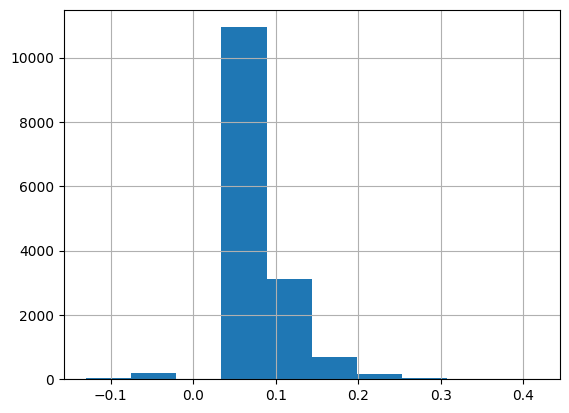

In [5]:
adata_peaks_ct_tp.obs["link_score"].hist()

In [21]:
import pandas as pd
import numpy as np

def create_peak_gene_associations(adata_peaks_ct_tp, overlap_score_value=0):
    """
    Create a dataframe of peak-gene associations with proper scoring
    
    Parameters:
    -----------
    adata_peaks_ct_tp : AnnData
        Peak-by-pseudobulk AnnData object
    overlap_score_value : float
        Score to assign to "overlap" associations (0, 0.5, or 1)
    
    Returns:
    --------
    DataFrame with peak-gene associations
    """
    
    print("=== CREATING PEAK-GENE ASSOCIATIONS DATAFRAME ===\n")
    
    # Step 1: Filter for peaks that have association_type not equal to "none"
    print("Step 1: Filtering peaks with valid associations...")
    
    # Get peaks with valid associations
    valid_association_mask = (adata_peaks_ct_tp.obs['association_type'] != 'none') & \
                           (adata_peaks_ct_tp.obs['association_type'].notna())
    
    print(f"✓ Total peaks: {len(adata_peaks_ct_tp.obs):,}")
    print(f"✓ Peaks with valid associations: {valid_association_mask.sum():,}")
    print(f"✓ Filtered out: {(~valid_association_mask).sum():,} peaks")
    
    # Check association types
    association_types = adata_peaks_ct_tp.obs['association_type'].value_counts()
    print(f"\nAssociation types distribution:")
    for assoc_type, count in association_types.items():
        print(f"  {assoc_type}: {count:,}")
    
    # Step 2: Extract relevant fields for valid associations
    print(f"\nStep 2: Extracting relevant fields...")
    
    # Define fields to extract
    fields_to_extract = [
        'associated_gene', 
        'association_type', 
        'link_score', 
        'link_pvalue'
    ]
    
    # Check if all fields exist
    missing_fields = [field for field in fields_to_extract if field not in adata_peaks_ct_tp.obs.columns]
    if missing_fields:
        print(f"⚠ Warning: Missing fields: {missing_fields}")
        fields_to_extract = [field for field in fields_to_extract if field in adata_peaks_ct_tp.obs.columns]
    
    print(f"✓ Extracting fields: {fields_to_extract}")
    
    # Create the filtered dataframe
    filtered_obs = adata_peaks_ct_tp.obs.loc[valid_association_mask, fields_to_extract].copy()
    
    # Step 3: Handle "overlap" associations
    print(f"\nStep 3: Processing overlap associations...")
    
    overlap_mask = filtered_obs['association_type'] == 'overlap'
    n_overlap = overlap_mask.sum()
    
    if n_overlap > 0:
        print(f"✓ Found {n_overlap:,} overlap associations")
        print(f"✓ Setting link_pvalue = NaN and link_score = {overlap_score_value}")
        
        # Set values for overlap associations
        filtered_obs.loc[overlap_mask, 'link_pvalue'] = np.nan
        filtered_obs.loc[overlap_mask, 'link_score'] = overlap_score_value
    else:
        print("✓ No overlap associations found")
    
    # Add additional useful information
    print(f"\nStep 4: Adding additional peak information...")
    
    additional_fields = [
        'leiden_coarse', 'leiden_unified'
    ]
    
    # Check which additional fields exist
    available_additional = [field for field in additional_fields if field in adata_peaks_ct_tp.obs.columns]
    print(f"✓ Adding additional fields: {available_additional}")
    
    # Add additional fields
    for field in available_additional:
        filtered_obs[field] = adata_peaks_ct_tp.obs.loc[valid_association_mask, field]
    
    # Reset index to make peak names a column
    filtered_obs = filtered_obs.reset_index()
    filtered_obs.rename(columns={'index': 'peak_id'}, inplace=True)
    
    print(f"\n=== RESULTS ===")
    print(f"✓ Created dataframe with {len(filtered_obs):,} peak-gene associations")
    print(f"✓ Columns: {list(filtered_obs.columns)}")
    
    return filtered_obs

# Create the associations dataframe
print("Creating peak-gene associations dataframe...")

# Option 1: Use 0 for overlap scores (conservative based on actual distribution)
peak_gene_df = create_peak_gene_associations(adata_peaks_ct_tp, overlap_score_value=0)
peak_gene_df = peak_gene_df.rename(columns={'leiden_unified': 'leiden_fine'})

# Display results
print("\n=== PREVIEW OF RESULTS ===")
print(peak_gene_df.head(10))

# Show statistics by association type
print(f"\n=== STATISTICS BY ASSOCIATION TYPE ===")
type_stats = peak_gene_df.groupby('association_type').agg({
    'peak_id': 'count',
    'link_score': ['mean', 'std', 'min', 'max'],
    'link_pvalue': ['count', 'mean']  # count shows non-NaN values
}).round(4)

print(type_stats)

# Save to CSV
output_filename = 'peaks_assoc_genes_filtered.csv'
peak_gene_df.to_csv(output_path + output_filename, index=True)
print(f"\n✓ Saved to '{output_filename}'")

Creating peak-gene associations dataframe...
=== CREATING PEAK-GENE ASSOCIATIONS DATAFRAME ===

Step 1: Filtering peaks with valid associations...
✓ Total peaks: 640,830
✓ Peaks with valid associations: 409,737
✓ Filtered out: 231,093 peaks

Association types distribution:
  overlap: 394,536
  none: 231,093
  linked: 15,201

Step 2: Extracting relevant fields...
✓ Extracting fields: ['associated_gene', 'association_type', 'link_score', 'link_pvalue']

Step 3: Processing overlap associations...
✓ Found 394,536 overlap associations
✓ Setting link_pvalue = NaN and link_score = 0

Step 4: Adding additional peak information...
✓ Adding additional fields: ['leiden_coarse', 'leiden_unified']

=== RESULTS ===
✓ Created dataframe with 409,737 peak-gene associations
✓ Columns: ['peak_id', 'associated_gene', 'association_type', 'link_score', 'link_pvalue', 'leiden_coarse', 'leiden_unified']

=== PREVIEW OF RESULTS ===
         peak_id associated_gene association_type  link_score    link_pvalue  \

/tmp/ipykernel_2156408/2822773132.py:115: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  type_stats = peak_gene_df.groupby('association_type').agg({



✓ Saved to 'peaks_assoc_genes_filtered.csv'


In [22]:
peak_gene_df.head()

,peak_id,associated_gene,association_type,link_score,link_pvalue,leiden_coarse,leiden_fine
0,1-4469-7268,rpl24,overlap,0.000000,NaN,26,26_9
1,1-9541-9969,rpl24,overlap,0.000000,NaN,33,33_6
2,1-11007-12962,cep97,overlap,0.000000,NaN,26,26_2
3,1-13276-13705,cep97,overlap,0.000000,NaN,33,33_3
4,1-14059-14260,rpl24,linked,-0.052304,4.950224e-12,33,33_6


### 3) cluster-by-motifs (enrichment score)

In [24]:
clust_by_motifs = pd.read_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/13_peak_umap_analysis/maelstrom_640K_leiden_coarse_cisBP_v2_danio_rerio_output/peak_clusts_by_motifs_maelstrom.csv", index_col=0)
# Strip "z-score " from column names
clust_by_motifs.columns = clust_by_motifs.columns.str.replace('z-score ', '')
clust_by_motifs.head()

,7,12,33,26,11,10,23,13,22,17,...,27,30,28,31,3,21,9,34,4,0
M04320_2.00,-1.368782,-1.292497,0.174508,0.115255,1.307492,1.780821,1.531623,1.502774,0.613629,-0.539151,...,-0.545107,-1.161936,0.575281,0.819190,-0.065967,1.584701,-1.127934,1.298611,-1.610902,-1.515982
M04454_2.00,-0.369697,-0.342407,0.025630,-0.303553,1.226708,0.219488,0.471395,-0.124502,-1.086451,0.346149,...,-0.723678,-1.046539,-2.607336,0.520146,-2.162172,0.161275,-0.538327,-2.856618,-0.663019,0.021287
M01720_2.00,0.988747,0.079956,-0.238793,0.007131,0.683540,-0.075378,0.424105,-0.878916,0.267999,-1.279960,...,-0.300357,1.461815,0.274771,0.376652,-0.347670,-1.017350,1.406330,1.778125,0.670667,-0.103173
M10186_2.00,1.306082,1.242187,-1.375008,-1.474846,-2.164871,-0.794959,-2.960422,-1.428110,-1.714684,-1.055767,...,-1.012179,0.439973,-1.492931,-1.431241,-0.981402,-1.524472,0.608953,-1.044115,1.306082,0.538858
M03731_2.00,-1.572697,-1.801436,-1.139508,-1.484947,-0.888929,-1.032306,-0.261045,-0.113256,1.080535,3.209698,...,0.424983,-2.376248,-0.203388,-0.062066,-0.705687,-1.584996,1.742122,0.090618,-2.139573,-1.588212


In [43]:
clust_by_motifs.to_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/objects_v2/leiden_by_motifs_maelstrom.csv")


In [34]:
# sanity check
df = pd.read_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/objects_v2/leiden_by_motifs_maelstrom.csv", index_col=0)
df.head()

,M04320_2.00,M04454_2.00,M01720_2.00,M10186_2.00,M03731_2.00,M04731_2.00,M04785_2.00,M02708_2.00,M00336_2.00,M04026_2.00,...,M06476_2.00,M02017_2.00,M06375_2.00,M08572_2.00,M06313_2.00,M02651_2.00,M10784_2.00,M08452_2.00,M10869_2.00,M06518_2.00
7,-1.368782,-0.369697,0.988747,1.306082,-1.572697,-1.347540,0.024850,1.216891,-0.962377,-0.956169,...,0.382885,1.929666,0.225133,2.097108,3.272975,1.766084,-2.053864,1.033707,1.907822,0.936034
12,-1.292497,-0.342407,0.079956,1.242187,-1.801436,-1.639597,0.062910,1.373438,-0.849191,-0.930442,...,0.780929,2.279517,0.482239,2.255553,3.281714,1.736472,-1.897626,0.559174,1.632902,0.612312
33,0.174508,0.025630,-0.238793,-1.375008,-1.139508,-0.960370,-0.658601,-1.154608,-2.564141,-0.832769,...,-1.672982,-0.038565,-2.422563,-0.989779,1.909328,-1.245577,-0.732930,-2.241918,-1.706974,-2.264252
26,0.115255,-0.303553,0.007131,-1.474846,-1.484947,0.433903,-0.152120,-1.225735,-2.716900,-0.382621,...,-1.601855,0.224392,-2.422563,-0.811669,2.232204,-1.245577,-0.564537,-2.241918,-1.706974,-2.264252
11,1.307492,1.226708,0.683540,-2.164871,-0.888929,1.245890,-0.437640,-2.335275,-2.373358,1.977257,...,-0.910050,-1.143654,-1.666987,-1.048229,0.789569,-1.861550,0.543802,-3.177755,-3.554546,-3.365767


### 3-2) fine-clusters: For this, we will use the per-peak motif.score.txt.gz file, then average them for each cluster


In [32]:
clust_by_motifs = pd.read_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/objects_v2/leiden_unified_by_motifs_maelstrom.csv",
                              index_col=0)
clust_by_motifs.head()

,M00008_2.00,M00045_2.00,M00056_2.00,M00066_2.00,M00070_2.00,M00111_2.00,M00112_2.00,M00113_2.00,M00114_2.00,M00115_2.00,...,M11341_2.00,M11342_2.00,M11367_2.00,M11368_2.00,M11371_2.00,M11384_2.00,M11388_2.00,M11389_2.00,M11390_2.00,M11491_2.00
cluster,,,,,,,,,,,,,,,,,,,,,
0_0,-0.570955,-0.512034,-0.313294,-0.416079,-0.472800,-0.043657,0.035966,-0.045672,0.075204,-0.397611,...,-0.364215,-0.497291,-0.445177,-0.275147,-0.530223,-0.399566,-0.471245,-0.683498,-0.490834,-0.471245
0_1,-0.528081,-0.127000,-0.189016,-0.267349,-0.234468,0.210946,0.318925,0.202516,0.386312,-0.265532,...,-0.070108,-0.156699,-0.330495,-0.033505,-0.315134,-0.304306,-0.338849,-0.462113,-0.304796,-0.338849
10_0,-0.373140,-0.092080,-0.349261,-0.127387,-0.316887,-0.144498,-0.141262,-0.166102,-0.137620,-0.408546,...,-0.208224,-0.197235,-0.247338,-0.228861,-0.177095,-0.057969,-0.184813,-0.251965,-0.233936,-0.184813
10_1,0.010059,0.165929,0.094294,0.190858,0.091154,0.222551,0.222204,0.236058,0.222543,0.101919,...,0.196648,0.191983,0.036053,0.094354,0.130800,0.270531,0.146607,0.189336,0.096031,0.146607
10_10,-0.079277,0.131900,0.026040,0.090025,0.099801,0.264970,0.276693,0.259466,0.288202,0.049120,...,0.160344,0.134197,0.007698,0.238180,0.127025,0.079424,0.195165,0.097309,0.146915,0.195165


### 4) We need to import the TFs for each motif as a dictionary/df

In [44]:
info_motifs = pd.read_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/13_peak_umap_analysis/maelstrom_640K_leiden_coarse_cisBP_v2_danio_rerio_output/info_cisBP_v2_danio_rerio_motif_factors.csv", index_col=0)
info_motifs.head()

,direct,indirect
motif,,
M00132_2.00,NaN,"myrf, osr2, osr1"
M00199_2.00,NaN,"sox19b, cica, sox5, sox11a, sox10, sox2, sox1b..."
M00210_2.00,NaN,"arid5b, foxg1b, sox2, foxa1, sox8a, sox7, sox4..."
M00216_2.00,NaN,"foxo4, irx7, foxg1b, foxo1b, barx1, dlx4a, hox..."
M00294_2.00,NaN,"hoxc13b, barhl1a, barx1, dlx4a, hoxb5b, hoxc11..."


In [45]:
info_motifs.to_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/objects_v2/info_cisBP_v2_danio_rerio_motif_factors.csv")

## Lastly, we need the number of "cells" for each pseudobulk group


In [26]:
# import the adata (cells-by-genes)
adata = sc.read_h5ad("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/integrated_RNA_ATAC_counts_RNA_master_filtered.h5ad")
adata

AnnData object with n_obs × n_vars = 94562 × 32057
    obs: 'orig_ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS_enrichment', 'TSS_percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT_weight', 'peaks_merged_weight', 'nCount_Gene_Activity', 'nFeature_Gene_Activity', 'nCount_peaks_integrated', 'nFeature_peaks_integrated', 'dataset', 'integrated_weight', 'peaks_integrated_weight', 'wsnn_res_0_8', 'seurat_clusters', 'data_source', 'annotation_ML', 'scANVI_zscape', 'annotation_ML_coarse', 'dev_stage'
    var: 'features'
    uns: 'annotation_ML_coarse_colors', 'annotation_ML_colors', 'dataset_colors', 'global_annotation_colors', 'log1p', 'scANVI_zscape_colors'
    obsm: 'X_umap.atac', 'X_umap.rna', 'X_wnn.umap'
    layers: 'counts'

In [28]:
def compute_cells_per_pseudobulk(adata, celltype_col='annotation_ML_coarse', timepoint_col='dev_stage'):
    """
    Compute number of cells per pseudobulk group (celltype_timepoint)
    
    Parameters:
    -----------
    adata : AnnData
        Single-cell AnnData object (cells-by-genes)
    celltype_col : str
        Column name for cell type annotation
    timepoint_col : str
        Column name for timepoint/developmental stage
    
    Returns:
    --------
    DataFrame with celltype_timepoint as index and cell counts
    """
    
    print("=== COMPUTING CELLS PER PSEUDOBULK GROUP ===\n")
    
    # Check if columns exist
    if celltype_col not in adata.obs.columns:
        print(f"❌ Error: Column '{celltype_col}' not found in adata.obs")
        return None
    
    if timepoint_col not in adata.obs.columns:
        print(f"❌ Error: Column '{timepoint_col}' not found in adata.obs")
        return None
    
    print(f"✓ Using celltype column: '{celltype_col}'")
    print(f"✓ Using timepoint column: '{timepoint_col}'")
    
    # Create combined celltype_timepoint identifier
    celltype_timepoint = adata.obs[celltype_col].astype(str) + '_' + adata.obs[timepoint_col].astype(str)
    
    # Count cells per group
    cell_counts = celltype_timepoint.value_counts().sort_index()
    
    # Create dataframe
    cells_per_pseudobulk_df = pd.DataFrame({
        'n_cells': cell_counts
    })
    
    # The index is already celltype_timepoint
    cells_per_pseudobulk_df.index.name = 'celltype_timepoint'
    
    print(f"✓ Computed cell counts for {len(cells_per_pseudobulk_df)} pseudobulk groups")
    print(f"✓ Total cells: {cells_per_pseudobulk_df['n_cells'].sum():,}")
    
    return cells_per_pseudobulk_df

# Compute the cell counts
cells_per_pseudobulk_df = compute_cells_per_pseudobulk(adata, 
                                                      celltype_col='annotation_ML_coarse', 
                                                      timepoint_col='dev_stage')

# Display results
print("\n=== RESULTS ===")
print(f"Shape: {cells_per_pseudobulk_df.shape}")
print(f"Columns: {list(cells_per_pseudobulk_df.columns)}")
print(f"Index: {cells_per_pseudobulk_df.index.name}")

print(f"\nFirst 10 pseudobulk groups:")
print(cells_per_pseudobulk_df.head(10))

print(f"\nLast 10 pseudobulk groups:")
print(cells_per_pseudobulk_df.tail(10))

# Summary statistics
print(f"\n=== SUMMARY STATISTICS ===")
print(f"Total pseudobulk groups: {len(cells_per_pseudobulk_df)}")
print(f"Total cells: {cells_per_pseudobulk_df['n_cells'].sum():,}")
print(f"Mean cells per group: {cells_per_pseudobulk_df['n_cells'].mean():.1f}")
print(f"Median cells per group: {cells_per_pseudobulk_df['n_cells'].median():.1f}")
print(f"Min cells per group: {cells_per_pseudobulk_df['n_cells'].min()}")
print(f"Max cells per group: {cells_per_pseudobulk_df['n_cells'].max()}")

# Show unique cell types and timepoints
print(f"\n=== UNIQUE VALUES ===")
unique_celltypes = adata.obs['annotation_ML_coarse'].unique()
unique_timepoints = adata.obs['dev_stage'].unique()

print(f"Unique cell types ({len(unique_celltypes)}): {sorted(unique_celltypes)}")
print(f"Unique timepoints ({len(unique_timepoints)}): {sorted(unique_timepoints)}")

# Save to CSV
output_filename = 'num_cells_per_pseudobulk_group.csv'
cells_per_pseudobulk_df.to_csv(output_path + output_filename)
print(f"\n✓ Saved to '{output_filename}'")

print(f"\n=== USAGE ===")
print("To access the dataframe: cells_per_pseudobulk_df")
print("To get cell count for specific group: cells_per_pseudobulk_df.loc['celltype_timepoint', 'n_cells']")

=== COMPUTING CELLS PER PSEUDOBULK GROUP ===

✓ Using celltype column: 'annotation_ML_coarse'
✓ Using timepoint column: 'dev_stage'
✓ Computed cell counts for 190 pseudobulk groups
✓ Total cells: 94,562

=== RESULTS ===
Shape: (190, 1)
Columns: ['n_cells']
Index: celltype_timepoint

First 10 pseudobulk groups:
                    n_cells
celltype_timepoint         
NMPs_0somites           630
NMPs_10somites          254
NMPs_15somites          340
NMPs_20somites           99
NMPs_30somites            6
NMPs_5somites           575
PSM_0somites           1316
PSM_10somites           560
PSM_15somites          1043
PSM_20somites           368

Last 10 pseudobulk groups:
                       n_cells
celltype_timepoint            
spinal_cord_15somites     1425
spinal_cord_20somites     1022
spinal_cord_30somites      319
spinal_cord_5somites       995
tail_bud_0somites         1056
tail_bud_10somites         483
tail_bud_15somites         609
tail_bud_20somites         198
tail_bud_30som

In [3]:
# import the datasets
# (1) peak clusters-by-pseudobulk groups
df_clusters_groups = pd.read_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/objects_v2/leiden_by_pseudobulk.csv",
                                 index_col=0)
# (2) peak clusters-by-associated genes
df_clusters_genes = pd.read_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/objects_v2/leiden_by_assoc_genes.csv",
                                index_col=0)
# (3) peak clusters-by-TF motifs
df_clusters_motifs = pd.read_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/objects_v2/leiden_by_motifs_maelstrom.csv",
                                 index_col=0)
# (4) motifs-by-factors
df_motif_info = pd.read_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/13_peak_umap_analysis/maelstrom_640K_leiden_coarse_cisBP_v2_danio_rerio_output/info_cisBP_v2_danio_rerio_motif_factors.csv", index_col=0)


# Take 2: 07/10/2025
Per Loic's request, we're adding some more statistics for the peak clusters (both coarse and fine)
- Number of peaks
- Genomic annotation distribution
- Distance to closest TSS
- Proportion of Peaks within 2kb of TSS.
- Full Chromosomal distribution in %  (maybe separate table)
- Median peak width

In [5]:
adata_peaks = sc.read_h5ad("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/objects_v2/peaks_by_pb_annotated_master.h5ad")
adata_peaks

AnnData object with n_obs × n_vars = 640830 × 190
    obs: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'accessibility_neural_optic', 'accessibility_endoderm', 'accessibility_enteric_neurons', 'accessibility_notochord', 'accessibility_pharyngeal_arches', 'accessibility_floor_plate', 'accessibility_epidermis', 'accessibility_pronephros', 'accessibility_neural_floor_plate', 'accessibility_lateral_plate_mesoderm', 'accessibility_midbrain_hindbrain_boundary', 'accessibility_neural', 'accessibility_neurons', 'accessibility_neural_posterior', 'accessibility_neural_crest', 'accessibility_PSM', 'accessibility_fast_muscle', 'accessibility_endocrine_pancreas', 'accessibility_heart_myocardium', 'accessibility_neural_telencephalon', 'accessibility_optic_cup', 'accessibility_primordial_germ_cells', 'accessibility_differentiating_neurons', 'accessibility_muscle', 'accessibility_tail_bud', 'accessibility_hindbrain', 'accessibility_somites', 'accessibility_spinal_cord',

In [10]:
# read the annotation for the "peak_type_argelaguet"
filepath = "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/all_peaks_annotated.csv"
annotated_peaks = pd.read_csv(filepath, index_col=0)
annotated_peaks.head()

,mean_counts,pct_dropout_by_counts,total_counts,accessibility_neural_optic,accessibility_endoderm,accessibility_enteric_neurons,accessibility_notochord,accessibility_pharyngeal_arches,accessibility_floor_plate,accessibility_epidermis,...,distance_to_tss,leiden_coarse,linked_gene,link_score,link_zscore,link_pvalue,associated_gene,association_type,log_total_counts,peak_type_argelaguet
n_cells_by_counts,,,,,,,,,,,,,,,,,,,,,
131,2.694737,31.052632,512.0,15.613128,10.325988,6.689899,2.991895,12.762588,12.170900,8.874177,...,11542.0,7,NaN,NaN,NaN,NaN,NaN,none,6.238325,intergenic
162,8.294737,14.736842,1576.0,57.789060,19.729371,42.719110,17.231317,22.624311,36.413397,30.458578,...,9107.0,12,NaN,NaN,NaN,NaN,NaN,none,7.362645,intergenic
170,18.636842,10.526316,3541.0,94.465606,30.845398,105.145162,41.163118,72.624480,72.500155,66.134746,...,8092.0,33,NaN,NaN,NaN,NaN,NaN,none,8.172164,intergenic
190,160.247368,0.000000,30447.0,568.299814,493.321985,480.077318,535.338964,641.692987,543.858841,572.097277,...,5953.0,26,NaN,NaN,NaN,NaN,rpl24,overlap,10.323743,exonic
172,33.905263,9.473684,6442.0,118.378152,102.449880,65.013071,141.397103,178.130543,108.393402,97.482937,...,2066.0,33,NaN,NaN,NaN,NaN,rpl24,overlap,8.770594,exonic


In [13]:
adata_peaks.obs["peak_type_argelaguet"] = annotated_peaks["peak_type_argelaguet"].values
adata_peaks.obs["peak_type_argelaguet"].head()

1-32-526       intergenic
1-2372-3057    intergenic
1-3427-4032    intergenic
1-4469-7268        exonic
1-9541-9969        exonic
Name: peak_type_argelaguet, dtype: object

Analyzing peak type annotations...
=== PEAK TYPE ANNOTATION COMPARISON ===

1. BASIC STATISTICS:
Total peaks: 640,830
Missing in peak_type: 0
Missing in peak_type_argelaguet: 0

2. UNIQUE VALUES:
peak_type categories: ['exonic', 'intergenic', 'intronic', 'promoter']
peak_type_argelaguet categories: ['exonic', 'intergenic', 'intronic', 'promoter']

3. VALUE COUNTS:
peak_type:
peak_type
intronic      257818
intergenic    221262
exonic        118236
promoter       43514
Name: count, dtype: int64

peak_type_argelaguet:
peak_type_argelaguet
intronic      260330
intergenic    233001
exonic        121077
promoter       26422
Name: count, dtype: int64

4. CROSS-TABULATION TABLE:
peak_type_argelaguet  exonic  intergenic  intronic  promoter     All
peak_type                                                           
exonic                118234           0         0         2  118236
intergenic                 0      221262         0         0  221262
intronic                   0           0    

/tmp/ipykernel_2088313/2508413372.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disagreement_patterns = disagreements.groupby(['peak_type', 'peak_type_argelaguet']).size().sort_values(ascending=False)


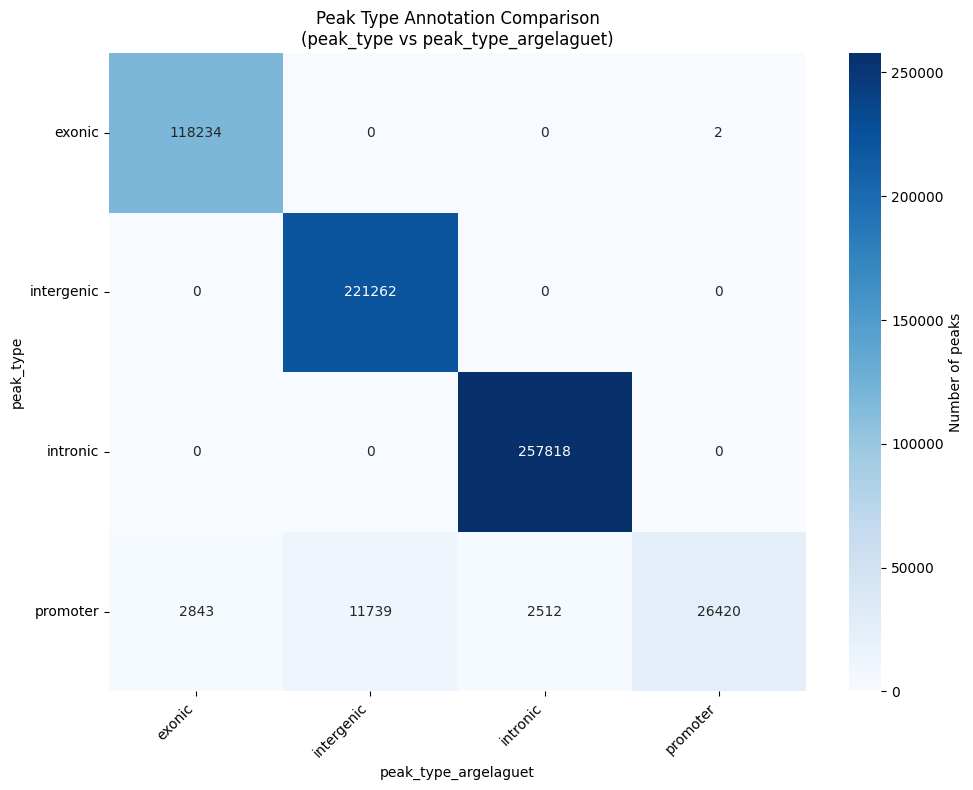


=== PERCENTAGE AGREEMENT MATRIX ===
Percentage breakdown by peak_type (rows sum to 100%):
peak_type_argelaguet  exonic  intergenic  intronic  promoter
peak_type                                                   
exonic                100.00        0.00      0.00      0.00
intergenic              0.00      100.00      0.00      0.00
intronic                0.00        0.00    100.00      0.00
promoter                6.53       26.98      5.77     60.72


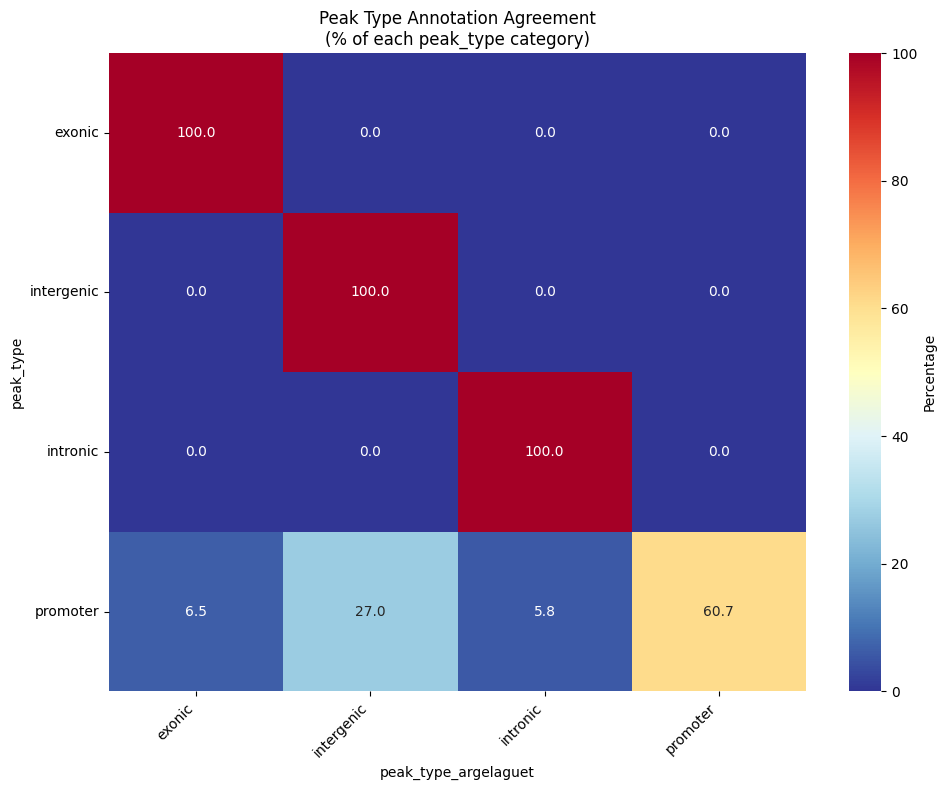


=== SUMMARY STATISTICS ===
Total comparable peaks: 640,830
Perfect agreement: 623,734
Accuracy: 0.9733 (97.33%)
Expected accuracy (chance): 0.3266
Cohen's Kappa: 0.9604
Kappa interpretation: Almost perfect agreement

=== SAVING RESULTS ===
✓ peak_type_disagreements.csv (17,096 rows)
✓ peak_type_comparison_crosstab.csv
Analysis complete!


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def compare_peak_annotations(adata_peaks):
    """
    Compare peak_type and peak_type_argelaguet annotations
    
    Parameters:
    -----------
    adata_peaks : AnnData
        Peak-by-pseudobulk AnnData object
    
    Returns:
    --------
    Various comparison analyses
    """
    
    # Extract the two annotation columns
    df = adata_peaks.obs[['peak_type', 'peak_type_argelaguet']].copy()
    
    print("=== PEAK TYPE ANNOTATION COMPARISON ===\n")
    
    # 1. Basic statistics
    print("1. BASIC STATISTICS:")
    print(f"Total peaks: {len(df):,}")
    print(f"Missing in peak_type: {df['peak_type'].isna().sum():,}")
    print(f"Missing in peak_type_argelaguet: {df['peak_type_argelaguet'].isna().sum():,}")
    
    # 2. Unique values in each column
    print("\n2. UNIQUE VALUES:")
    print("peak_type categories:", sorted(df['peak_type'].dropna().unique()))
    print("peak_type_argelaguet categories:", sorted(df['peak_type_argelaguet'].dropna().unique()))
    
    # 3. Value counts for each annotation
    print("\n3. VALUE COUNTS:")
    print("peak_type:")
    print(df['peak_type'].value_counts())
    print("\npeak_type_argelaguet:")
    print(df['peak_type_argelaguet'].value_counts())
    
    # 4. Cross-tabulation (contingency table)
    print("\n4. CROSS-TABULATION TABLE:")
    crosstab = pd.crosstab(df['peak_type'], df['peak_type_argelaguet'], 
                          margins=True, dropna=False)
    print(crosstab)
    
    # 5. Percentage agreement
    print("\n5. AGREEMENT ANALYSIS:")
    
    # Remove rows with missing values for agreement calculation
    df_clean = df.dropna()
    
    if len(df_clean) > 0:
        # Calculate exact agreement
        exact_agreement = (df_clean['peak_type'] == df_clean['peak_type_argelaguet']).sum()
        total_comparable = len(df_clean)
        agreement_pct = (exact_agreement / total_comparable) * 100
        
        print(f"Exact agreement: {exact_agreement:,} / {total_comparable:,} ({agreement_pct:.2f}%)")
        print(f"Disagreement: {total_comparable - exact_agreement:,} ({100 - agreement_pct:.2f}%)")
    
    # 6. Detailed disagreement analysis
    print("\n6. DISAGREEMENT PATTERNS:")
    disagreements = df_clean[df_clean['peak_type'] != df_clean['peak_type_argelaguet']]
    
    if len(disagreements) > 0:
        print(f"Number of disagreements: {len(disagreements):,}")
        print("\nMost common disagreement patterns:")
        disagreement_patterns = disagreements.groupby(['peak_type', 'peak_type_argelaguet']).size().sort_values(ascending=False)
        print(disagreement_patterns.head(10))
        
        # Show some examples
        print(f"\nExample disagreements (first 10):")
        example_cols = ['peak_type', 'peak_type_argelaguet']
        if 'chrom' in adata_peaks.obs.columns:
            example_cols.extend(['chrom', 'start', 'end'])
        if 'nearest_gene' in adata_peaks.obs.columns:
            example_cols.append('nearest_gene')
            
        examples = adata_peaks.obs.loc[disagreements.index[:10], example_cols]
        print(examples.to_string())
        
    return crosstab, disagreements

# Run the comparison
print("Analyzing peak type annotations...")
crosstab, disagreements = compare_peak_annotations(adata_peaks)

# 7. Create a heatmap of the cross-tabulation
print("\n=== CREATING VISUALIZATION ===")

# Prepare data for heatmap (exclude margins)
heatmap_data = crosstab.iloc[:-1, :-1]  # Remove 'All' row and column

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='Blues', 
            cbar_kws={'label': 'Number of peaks'})
plt.title('Peak Type Annotation Comparison\n(peak_type vs peak_type_argelaguet)')
plt.xlabel('peak_type_argelaguet')
plt.ylabel('peak_type')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 8. Agreement matrix (normalized)
print("\n=== PERCENTAGE AGREEMENT MATRIX ===")
# Calculate percentages
pct_crosstab = crosstab.iloc[:-1, :-1].div(crosstab.iloc[:-1, -1], axis=0) * 100
print("Percentage breakdown by peak_type (rows sum to 100%):")
print(pct_crosstab.round(2))

# Create percentage heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(pct_crosstab, annot=True, fmt='.1f', cmap='RdYlBu_r', 
            cbar_kws={'label': 'Percentage'})
plt.title('Peak Type Annotation Agreement\n(% of each peak_type category)')
plt.xlabel('peak_type_argelaguet')
plt.ylabel('peak_type')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 9. Summary statistics
print("\n=== SUMMARY STATISTICS ===")
def calculate_agreement_stats(crosstab_matrix):
    """Calculate various agreement statistics"""
    
    # Extract the data matrix (without margins)
    data = crosstab_matrix.iloc[:-1, :-1].values
    
    # Total observations
    total = data.sum()
    
    # Diagonal (perfect agreement)
    diagonal_sum = np.trace(data)
    
    # Overall accuracy
    accuracy = diagonal_sum / total
    
    # Expected accuracy (chance agreement)
    row_marginals = data.sum(axis=1) / total
    col_marginals = data.sum(axis=0) / total
    expected_accuracy = np.sum(row_marginals * col_marginals)
    
    # Cohen's Kappa
    if expected_accuracy < 1:
        kappa = (accuracy - expected_accuracy) / (1 - expected_accuracy)
    else:
        kappa = 1.0
    
    return {
        'total_peaks': int(total),
        'diagonal_agreement': int(diagonal_sum),
        'accuracy': accuracy,
        'expected_accuracy': expected_accuracy,
        'kappa': kappa
    }

if len(crosstab.iloc[:-1, :-1]) > 0:
    stats = calculate_agreement_stats(crosstab)
    
    print(f"Total comparable peaks: {stats['total_peaks']:,}")
    print(f"Perfect agreement: {stats['diagonal_agreement']:,}")
    print(f"Accuracy: {stats['accuracy']:.4f} ({stats['accuracy']*100:.2f}%)")
    print(f"Expected accuracy (chance): {stats['expected_accuracy']:.4f}")
    print(f"Cohen's Kappa: {stats['kappa']:.4f}")
    
    # Interpret Kappa
    if stats['kappa'] > 0.8:
        interpretation = "Almost perfect agreement"
    elif stats['kappa'] > 0.6:
        interpretation = "Substantial agreement"
    elif stats['kappa'] > 0.4:
        interpretation = "Moderate agreement"
    elif stats['kappa'] > 0.2:
        interpretation = "Fair agreement"
    else:
        interpretation = "Poor agreement"
    
    print(f"Kappa interpretation: {interpretation}")

# 10. Save results
print("\n=== SAVING RESULTS ===")

# Save cross-tabulation
crosstab.to_csv('peak_type_comparison_crosstab.csv')

# Save disagreements
if len(disagreements) > 0:
    disagreement_details = adata_peaks.obs.loc[disagreements.index]
    disagreement_details.to_csv('peak_type_disagreements.csv')
    print(f"✓ peak_type_disagreements.csv ({len(disagreements):,} rows)")

print("✓ peak_type_comparison_crosstab.csv")
print("Analysis complete!")

In [39]:
# A function to compute the stats from "adata_peaks", for "cluster_col" clustering resolution
def compute_peak_cluster_stats(adata_peaks, cluster_col):
    """
    Compute cluster-level statistics for peak clusters
    
    Parameters:
    -----------
    adata_peaks : AnnData
        Peak-by-pseudobulk AnnData object
    cluster_col : str
        Column name for clustering ('leiden_coarse' or 'leiden_unified')
    
    Returns:
    --------
    stats_df : DataFrame
        Cluster statistics dataframe
    chrom_df : DataFrame  
        Chromosomal distribution dataframe
    """
    
    # Convert to pandas DataFrame for easier manipulation
    df = adata_peaks.obs.copy()
    
    # Initialize results dictionary
    stats_results = []
    
    # Get unique clusters
    clusters = df[cluster_col].unique()
    clusters = sorted([c for c in clusters if pd.notna(c)])
    
    for cluster in clusters:
        cluster_data = df[df[cluster_col] == cluster]
        
        # 1. Number of peaks
        n_peaks = len(cluster_data)
        
        # 2. Genomic annotation distribution
        peak_type_counts = cluster_data['peak_type_argelaguet'].value_counts()
        total_peaks = len(cluster_data)
        
        # Get percentages for each peak type
        pct_intergenic = (peak_type_counts.get('intergenic', 0) / total_peaks) * 100
        pct_intronic = (peak_type_counts.get('intronic', 0) / total_peaks) * 100
        pct_exonic = (peak_type_counts.get('exonic', 0) / total_peaks) * 100
        pct_promoter = (peak_type_counts.get('promoter', 0) / total_peaks) * 100
        
        # 3. Distance to closest TSS statistics
        tss_distances = cluster_data['distance_to_tss'].dropna()
        median_tss_dist = tss_distances.median() if len(tss_distances) > 0 else np.nan
        q25_tss_dist = tss_distances.quantile(0.25) if len(tss_distances) > 0 else np.nan
        q75_tss_dist = tss_distances.quantile(0.75) if len(tss_distances) > 0 else np.nan
        
        # 4. Proportion of peaks within 2kb of TSS
        within_2kb = (tss_distances.abs() <= 2000).sum() if len(tss_distances) > 0 else 0
        pct_within_2kb = (within_2kb / len(tss_distances)) * 100 if len(tss_distances) > 0 else 0
        
        # 5. Median peak width
        median_peak_width = cluster_data['length'].median()
        
        # Store results
        stats_results.append({
            'cluster': cluster,
            'n_peaks': n_peaks,
            'pct_intergenic': round(pct_intergenic, 2),
            'pct_intronic': round(pct_intronic, 2),
            'pct_exonic': round(pct_exonic, 2),
            'pct_promoter': round(pct_promoter, 2),
            'median_tss_distance': round(median_tss_dist, 0) if not pd.isna(median_tss_dist) else np.nan,
            'q25_tss_distance': round(q25_tss_dist, 0) if not pd.isna(q25_tss_dist) else np.nan,
            'q75_tss_distance': round(q75_tss_dist, 0) if not pd.isna(q75_tss_dist) else np.nan,
            'pct_within_2kb_tss': round(pct_within_2kb, 2),
            'median_peak_width': round(median_peak_width, 0)
        })
    
    stats_df = pd.DataFrame(stats_results)
    
  # Chromosomal distribution (separate table)
    chrom_results = []
    for cluster in clusters:
        cluster_data = df[df[cluster_col] == cluster]
        chrom_counts = cluster_data['chrom'].value_counts()
        total_peaks = len(cluster_data)
        
        chrom_dist = {}
        for chrom in chrom_counts.index:
            pct = (chrom_counts[chrom] / total_peaks) * 100
            chrom_dist[f'chr_{chrom}'] = round(pct, 2)
        
        chrom_dist['cluster'] = cluster
        chrom_results.append(chrom_dist)
    
    chrom_df = pd.DataFrame(chrom_results)
    # Move cluster column to front and order chromosome columns numerically
    chrom_cols = [col for col in chrom_df.columns if col.startswith('chr_')]
    
    # Sort chromosome columns numerically
    def extract_chrom_number(col_name):
        try:
            return int(col_name.replace('chr_', ''))
        except ValueError:
            return float('inf')  # Put non-numeric chromosomes at the end
    
    chrom_cols_sorted = sorted(chrom_cols, key=extract_chrom_number)
    
    cols = ['cluster'] + chrom_cols_sorted
    chrom_df = chrom_df[cols]
    
    return stats_df, chrom_df



In [43]:
# Compute statistics for both clustering levels
print("Computing cluster statistics...")

# Coarse clusters
coarse_stats_df, coarse_chrom_df = compute_peak_cluster_stats(adata_peaks, 'leiden_coarse')
print(f"Coarse clustering: {len(coarse_stats_df)} clusters")

# Fine clusters  
fine_stats_df, fine_chrom_df = compute_peak_cluster_stats(adata_peaks, 'leiden_unified')
print(f"Fine clustering: {len(fine_stats_df)} clusters")

# Display sample results
print("\n=== COARSE CLUSTER STATISTICS (first 5 rows) ===")
coarse_stats_df.set_index("cluster", inplace=True)
print(coarse_stats_df.head())

print("\n=== FINE CLUSTER STATISTICS (first 5 rows) ===")
fine_stats_df.set_index("cluster", inplace=True)
print(fine_stats_df.head())

print("\n=== CHROMOSOMAL DISTRIBUTION - COARSE (first 3 rows) ===")
coarse_chrom_df.set_index("cluster", inplace=True)
fine_chrom_df.set_index("cluster", inplace=True)
print(coarse_chrom_df.head(3))

# Save to CSV files\
savepath = "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/objects_v2/"
coarse_stats_df.to_csv(savepath + 'coarse_cluster_statistics.csv', index=True)
fine_stats_df.to_csv(savepath + 'fine_cluster_statistics.csv', index=True)
coarse_chrom_df.to_csv(savepath + 'coarse_chrom_distribution.csv', index=True)
fine_chrom_df.to_csv(savepath + 'fine_chrom_distribution.csv', index=True)

print("\n=== FILES SAVED ===")
print("✓ coarse_cluster_statistics.csv")
print("✓ fine_cluster_statistics.csv") 
print("✓ coarse_chromosomal_distribution.csv")
print("✓ fine_chromosomal_distribution.csv")

# Summary statistics
print(f"\n=== SUMMARY ===")
print(f"Coarse clusters: {len(coarse_stats_df)}")
print(f"Fine clusters: {len(fine_stats_df)}")
print(f"Total peaks analyzed: {len(adata_peaks.obs)}")
print(f"Chromosomes detected: {sorted(adata_peaks.obs['chrom'].unique())}")

Computing cluster statistics...
Coarse clustering: 36 clusters
Fine clustering: 402 clusters

=== COARSE CLUSTER STATISTICS (first 5 rows) ===
         n_peaks  pct_intergenic  pct_intronic  pct_exonic  pct_promoter  \
cluster                                                                    
0            451           44.57         45.90        8.65          0.89   
1          69950           37.68         43.42       17.55          1.35   
2          26284           36.05         40.92       20.94          2.09   
3           7692           40.85         45.40       12.52          1.24   
4           6964           41.71         43.14       13.73          1.42   

         median_tss_distance  q25_tss_distance  q75_tss_distance  \
cluster                                                            
0                    15584.0            7304.0           24853.0   
1                    14168.0            6800.0           26084.0   
2                    14131.0            6176.0      

In [41]:
coarse_stats_df.head()

,n_peaks,pct_intergenic,pct_intronic,pct_exonic,pct_promoter,median_tss_distance,q25_tss_distance,q75_tss_distance,pct_within_2kb_tss,median_peak_width
cluster,,,,,,,,,,
0,451,44.57,45.90,8.65,0.89,15584.0,7304.0,24853.0,4.64,401.0
1,69950,37.68,43.42,17.55,1.35,14168.0,6800.0,26084.0,6.61,424.0
2,26284,36.05,40.92,20.94,2.09,14131.0,6176.0,26924.0,7.48,628.0
3,7692,40.85,45.40,12.52,1.24,17329.0,7914.0,30244.0,5.14,691.0
4,6964,41.71,43.14,13.73,1.42,14332.0,6714.0,26314.0,6.59,378.0


In [42]:
coarse_chrom_df.head()

,chr_1,chr_2,chr_3,chr_4,chr_5,chr_6,chr_7,chr_8,chr_9,chr_10,...,chr_16,chr_17,chr_18,chr_19,chr_20,chr_21,chr_22,chr_23,chr_24,chr_25
cluster,,,,,,,,,,,,,,,,,,,,,
0,5.32,2.66,2.88,4.88,4.43,3.55,5.10,4.21,6.87,3.10,...,3.10,5.54,2.66,4.66,5.10,3.99,0.89,2.00,6.65,3.55
1,4.76,4.58,4.75,3.20,5.58,4.52,5.37,4.30,4.25,3.25,...,4.20,4.17,3.82,3.57,4.75,3.40,3.01,3.32,3.47,3.02
2,4.57,4.40,4.79,3.46,5.35,4.60,5.51,4.31,4.29,3.60,...,4.28,3.93,3.92,3.84,4.20,3.60,2.54,3.44,3.53,2.88
3,4.30,4.46,3.26,3.42,5.08,4.84,6.62,4.45,4.73,3.38,...,4.06,4.24,3.87,3.67,3.93,3.07,3.00,3.06,3.58,3.09
4,5.08,4.32,4.77,3.33,6.06,4.29,5.53,4.29,4.24,3.48,...,4.09,4.01,4.24,3.22,4.35,3.79,2.91,3.22,3.63,3.20


Text(0, 0.5, 'pct_within_2kb_TSS')

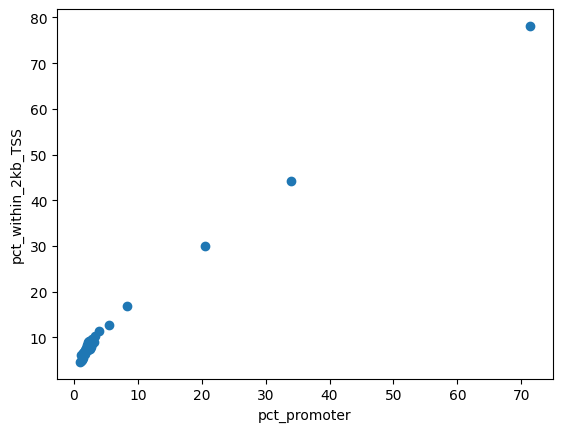

In [31]:
plt.scatter(coarse_stats_df["pct_promoter"], coarse_stats_df["pct_within_2kb_tss"])
plt.xlabel("pct_promoter")
plt.ylabel("pct_within_2kb_TSS")

Plotting individual peak TSS distances by coarse clusters...
Plotting 500,582 individual peaks across 36 clusters


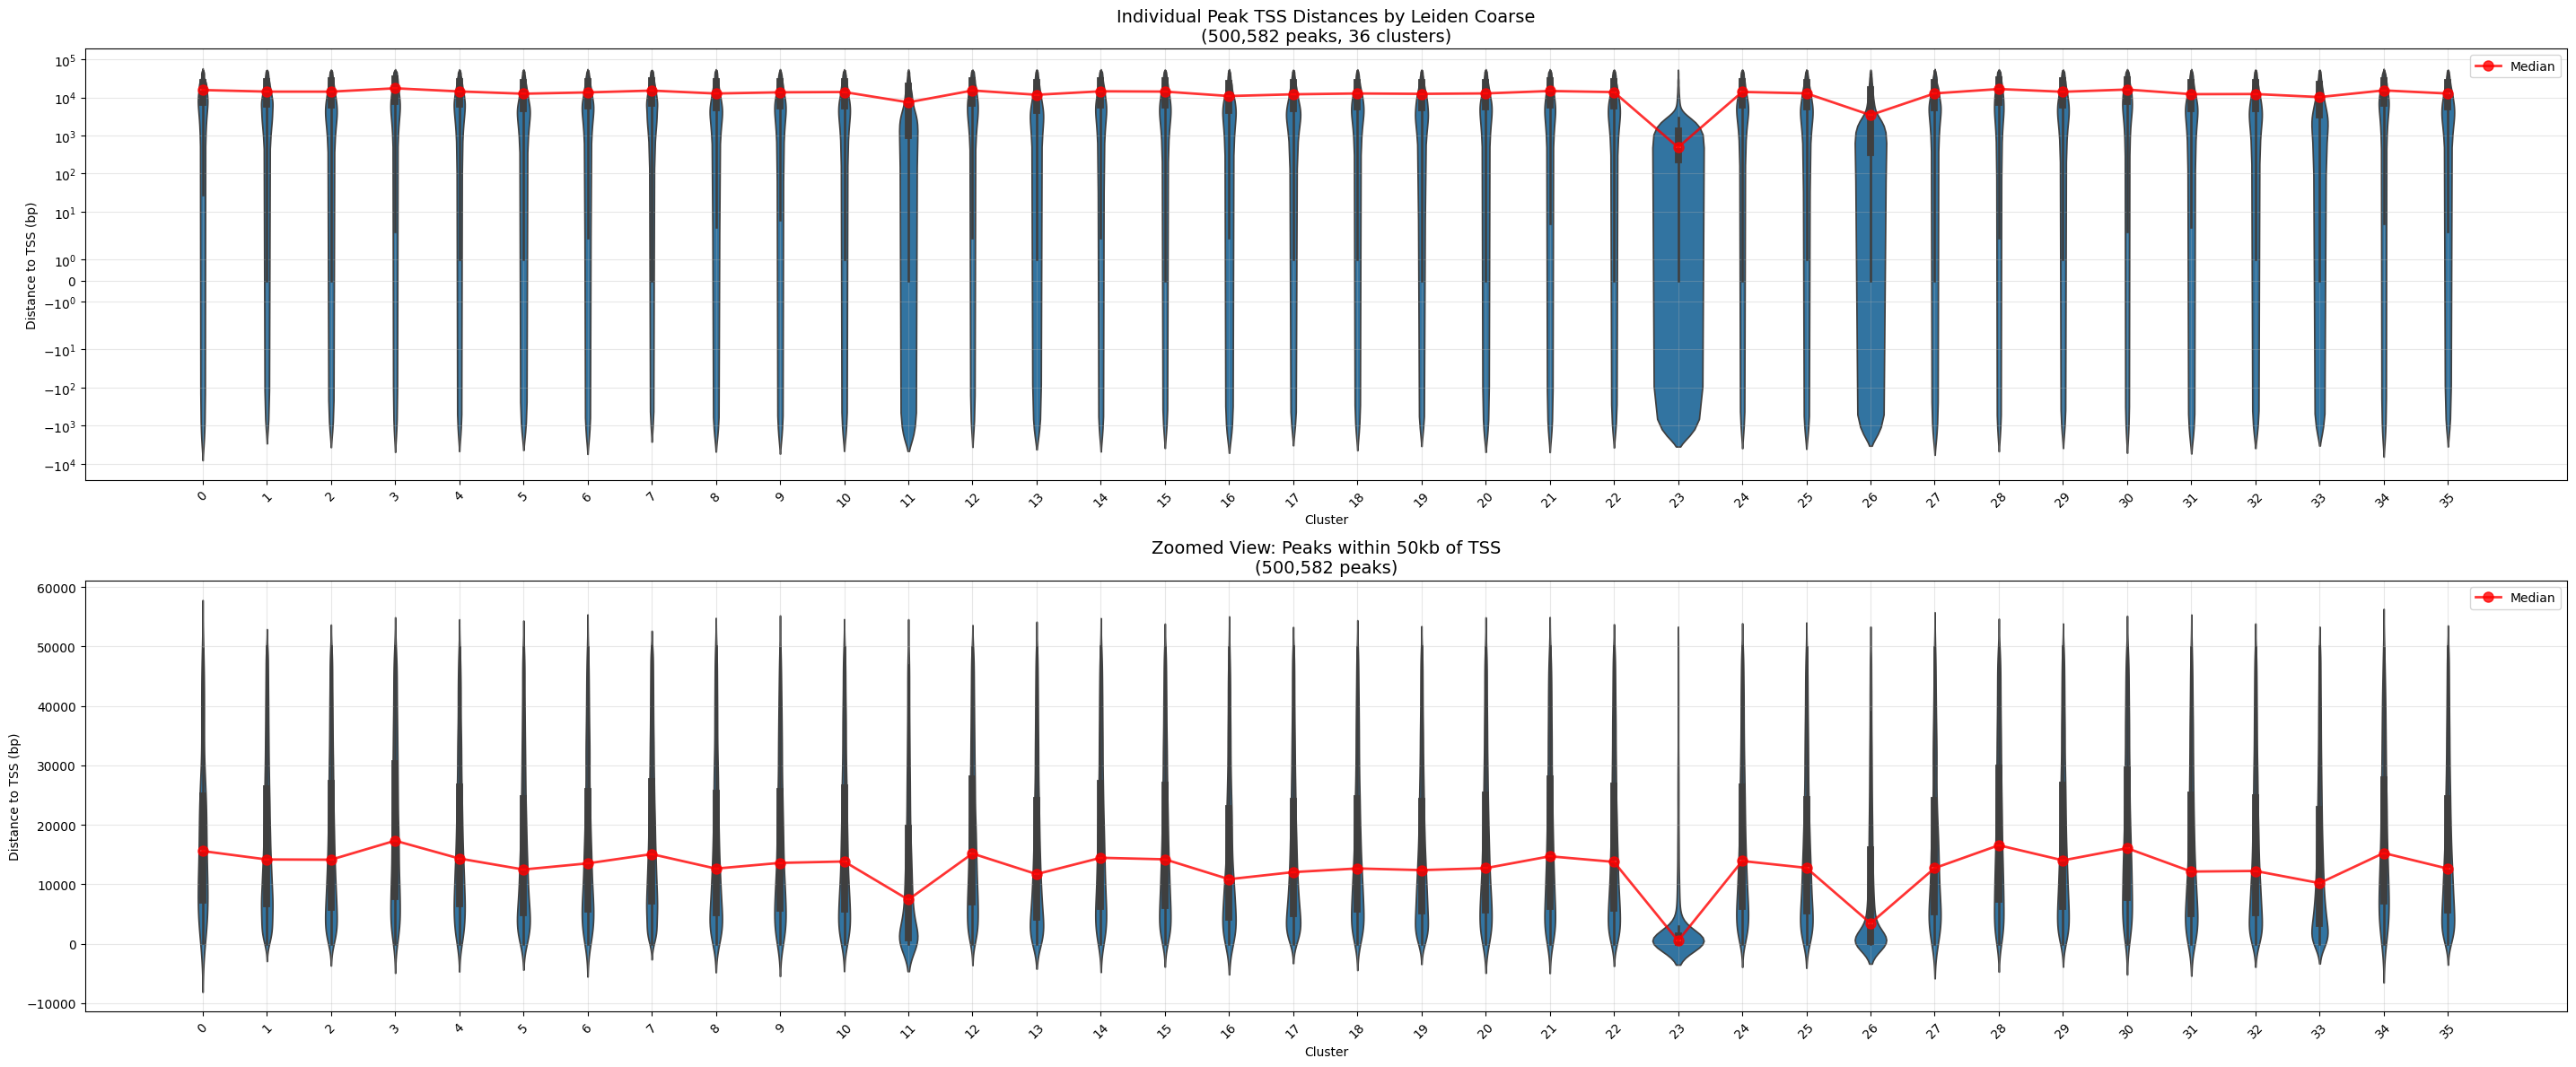


=== CLUSTER SUMMARY ===
   cluster  n_peaks  median_tss_dist  mean_tss_dist      q25       q75  \
0        0      302          15584.0       17889.30  7304.25  24852.75   
1        1    54300          14167.5       17464.64  6800.00  26083.75   
2        2    20099          14131.0       17492.98  6175.50  26923.50   
3        3     5291          17329.0       19768.23  7913.50  30244.00   
4        4     5247          14332.0       17542.39  6714.50  26314.00   
5        5     7629          12479.0       16113.50  5189.00  24391.00   
6        6     2422          13511.5       16815.91  5891.25  25544.00   
7        7    96658          15068.5       18149.80  7206.00  27219.00   
8        8     5187          12632.0       16427.14  5252.00  25307.00   
9        9     2550          13591.5       16875.97  5923.25  25653.25   
10      10     6358          13831.5       17125.47  5858.00  26185.00   
11      11     5822           7410.5       12211.56  1009.50  19347.00   
12      12   

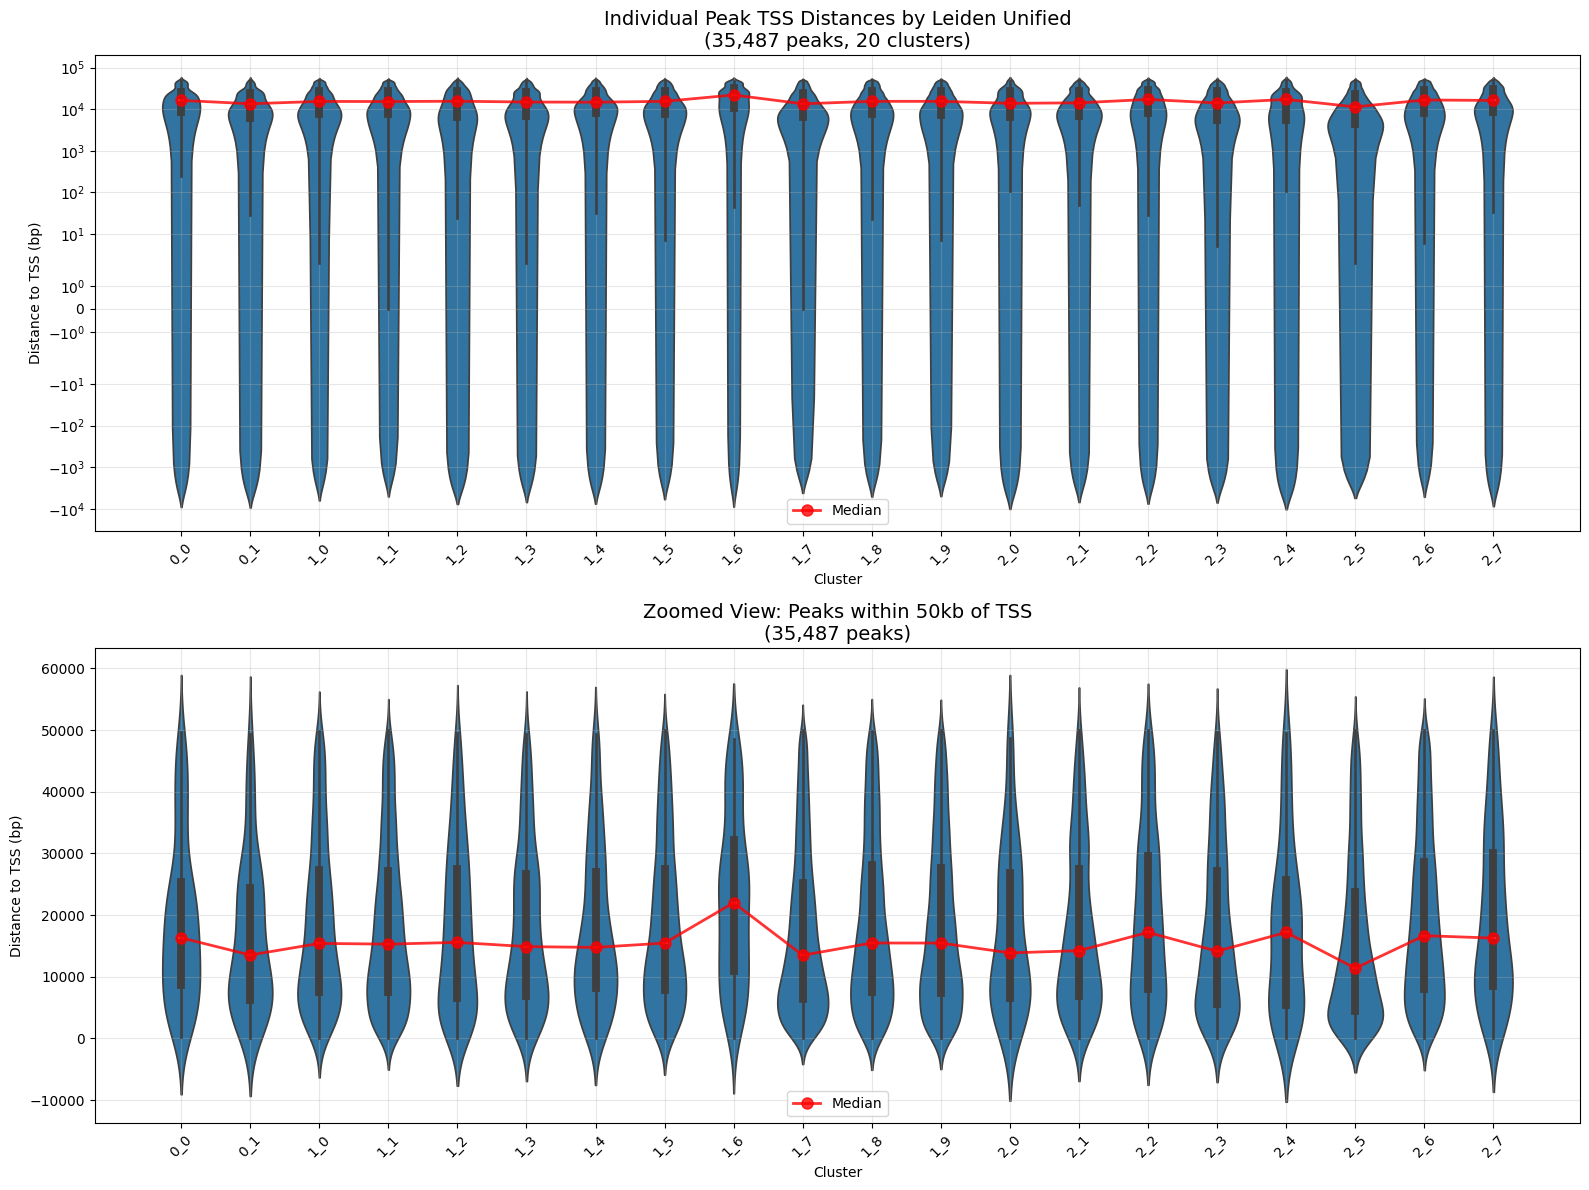


=== CLUSTER SUMMARY ===
   cluster  n_peaks  median_tss_dist  mean_tss_dist       q25       q75  \
0      0_0      178          16330.0       18846.76   8701.50  25372.75   
1      0_1      124          13534.0       16514.90   6189.50  24344.25   
2      1_0     1290          15416.5       18487.13   7492.50  27275.50   
3      1_1     3584          15303.0       18237.52   7618.75  27088.75   
4      1_2      477          15584.0       18026.26   6633.00  27442.00   
5      1_3      718          14900.5       17826.03   6951.75  26636.25   
6      1_4      457          14768.0       17863.16   8135.00  26929.00   
7      1_5     1723          15470.0       18525.27   7799.50  27537.00   
8      1_6      244          22016.0       22449.87  10990.75  32162.50   
9      1_7     9450          13499.5       16969.80   6383.25  25264.75   
10     1_8     4021          15484.0       18625.83   7554.00  28063.00   
11     1_9     4267          15476.0       18308.02   7428.00  27728.00   


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

def plot_individual_peak_tss_distances(adata_peaks, cluster_col='leiden_coarse', 
                                     max_clusters=None, plot_type='violin'):
    """
    Plot individual peak TSS distances grouped by cluster with median overlay
    
    Parameters:
    -----------
    adata_peaks : AnnData
        Peak-by-pseudobulk AnnData object
    cluster_col : str
        Column name for clustering (default: 'leiden_coarse')
    max_clusters : int
        Maximum number of clusters to plot (None = all)
    plot_type : str
        Type of plot: 'violin', 'box', 'strip', or 'swarm'
    """
    
    # Extract data
    df = adata_peaks.obs[[cluster_col, 'distance_to_tss']].copy()
    
    # Remove missing values
    df = df.dropna()
    
    # Convert cluster to string for better plotting
    df[cluster_col] = df[cluster_col].astype(str)
    
    # Sort clusters numerically if possible
    try:
        cluster_order = sorted(df[cluster_col].unique(), key=lambda x: int(x))
    except:
        cluster_order = sorted(df[cluster_col].unique())
    
    # Limit clusters if requested
    if max_clusters is not None:
        cluster_order = cluster_order[:max_clusters]
        df = df[df[cluster_col].isin(cluster_order)]
    
    print(f"Plotting {len(df):,} individual peaks across {len(cluster_order)} clusters")
    
    # Calculate median values for each cluster
    medians = df.groupby(cluster_col)['distance_to_tss'].median()
    
    # Create the plot
    fig, axes = plt.subplots(2, 1, figsize=(max(12, len(cluster_order) * 0.8), 12))
    
    # Plot 1: Full range (with symlog scale)
    ax1 = axes[0]
    
    if plot_type == 'violin':
        sns.violinplot(data=df, x=cluster_col, y='distance_to_tss', 
                      order=cluster_order, ax=ax1, inner='box')
    elif plot_type == 'box':
        sns.boxplot(data=df, x=cluster_col, y='distance_to_tss', 
                   order=cluster_order, ax=ax1)
    elif plot_type == 'strip':
        sns.stripplot(data=df, x=cluster_col, y='distance_to_tss', 
                     order=cluster_order, ax=ax1, alpha=0.5, size=1)
    elif plot_type == 'swarm':
        # For swarm plot, we might need to sample data if too many points
        if len(df) > 10000:
            df_sample = df.sample(n=10000, random_state=42)
            print(f"Sampling {len(df_sample):,} peaks for swarm plot")
        else:
            df_sample = df
        sns.swarmplot(data=df_sample, x=cluster_col, y='distance_to_tss', 
                     order=cluster_order, ax=ax1, alpha=0.6, size=2)
    
    # Overlay median values
    median_values = [medians[cluster] for cluster in cluster_order]
    ax1.plot(range(len(cluster_order)), median_values, 
             'ro-', linewidth=2, markersize=8, label='Median', alpha=0.8)
    
    ax1.set_title(f'Individual Peak TSS Distances by {cluster_col.replace("_", " ").title()}\n'
                 f'({len(df):,} peaks, {len(cluster_order)} clusters)', fontsize=14)
    ax1.set_xlabel('Cluster')
    ax1.set_ylabel('Distance to TSS (bp)')
    ax1.set_yscale('symlog')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Rotate x-axis labels if many clusters
    if len(cluster_order) > 10:
        ax1.tick_params(axis='x', rotation=45)
    
    # Plot 2: Zoomed in version (linear scale, limited range)
    ax2 = axes[1]
    
    # Filter for closer peaks (within 50kb)
    df_close = df[df['distance_to_tss'].abs() <= 50000]
    
    if plot_type == 'violin':
        sns.violinplot(data=df_close, x=cluster_col, y='distance_to_tss', 
                      order=cluster_order, ax=ax2, inner='box')
    elif plot_type == 'box':
        sns.boxplot(data=df_close, x=cluster_col, y='distance_to_tss', 
                   order=cluster_order, ax=ax2)
    elif plot_type == 'strip':
        sns.stripplot(data=df_close, x=cluster_col, y='distance_to_tss', 
                     order=cluster_order, ax=ax2, alpha=0.5, size=1)
    elif plot_type == 'swarm':
        if len(df_close) > 10000:
            df_close_sample = df_close.sample(n=10000, random_state=42)
        else:
            df_close_sample = df_close
        sns.swarmplot(data=df_close_sample, x=cluster_col, y='distance_to_tss', 
                     order=cluster_order, ax=ax2, alpha=0.6, size=2)
    
    # Overlay median values (only for clusters with data in this range)
    medians_close = df_close.groupby(cluster_col)['distance_to_tss'].median()
    median_values_close = []
    x_positions = []
    
    for i, cluster in enumerate(cluster_order):
        if cluster in medians_close.index:
            median_values_close.append(medians_close[cluster])
            x_positions.append(i)
    
    ax2.plot(x_positions, median_values_close, 
             'ro-', linewidth=2, markersize=8, label='Median', alpha=0.8)
    
    ax2.set_title(f'Zoomed View: Peaks within 50kb of TSS\n'
                 f'({len(df_close):,} peaks)', fontsize=14)
    ax2.set_xlabel('Cluster')
    ax2.set_ylabel('Distance to TSS (bp)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Rotate x-axis labels if many clusters
    if len(cluster_order) > 10:
        ax2.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\n=== CLUSTER SUMMARY ===")
    summary_stats = []
    
    for cluster in cluster_order:
        cluster_data = df[df[cluster_col] == cluster]['distance_to_tss']
        
        stats_dict = {
            'cluster': cluster,
            'n_peaks': len(cluster_data),
            'median_tss_dist': cluster_data.median(),
            'mean_tss_dist': cluster_data.mean(),
            'q25': cluster_data.quantile(0.25),
            'q75': cluster_data.quantile(0.75),
            'within_2kb': (cluster_data.abs() <= 2000).sum(),
            'within_2kb_pct': (cluster_data.abs() <= 2000).mean() * 100
        }
        summary_stats.append(stats_dict)
    
    summary_df = pd.DataFrame(summary_stats)
    print(summary_df.round(2))
    
    return summary_df

# Plot individual peak TSS distances
print("Plotting individual peak TSS distances by coarse clusters...")
summary_coarse = plot_individual_peak_tss_distances(adata_peaks, 
                                                   cluster_col='leiden_coarse',
                                                   plot_type='violin')

# Also create a version with fine clusters (if you want to compare)
print("\n" + "="*50)
print("Plotting individual peak TSS distances by fine clusters...")
summary_fine = plot_individual_peak_tss_distances(adata_peaks, 
                                                 cluster_col='leiden_unified',
                                                 max_clusters=20,  # Limit to first 20 for visibility
                                                 plot_type='violin')

# Create a comparison plot of the calculated medians vs actual medians
def compare_calculated_vs_actual_medians(adata_peaks, cluster_stats_file, 
                                       cluster_col='leiden_coarse'):
    """
    Compare the medians we calculated from cluster statistics vs actual medians
    """
    
    # Load calculated cluster statistics
    try:
        cluster_stats = pd.read_csv(cluster_stats_file)
    except FileNotFoundError:
        print(f"Could not find {cluster_stats_file}")
        return
    
    # Calculate actual medians from individual peaks
    df = adata_peaks.obs[[cluster_col, 'distance_to_tss']].copy().dropna()
    df[cluster_col] = df[cluster_col].astype(str)
    actual_medians = df.groupby(cluster_col)['distance_to_tss'].median()
    
    # Merge with calculated medians
    comparison_data = []
    for _, row in cluster_stats.iterrows():
        cluster_id = str(row['cluster'])
        if cluster_id in actual_medians.index:
            comparison_data.append({
                'cluster': cluster_id,
                'calculated_median': row['median_tss_distance'],
                'actual_median': actual_medians[cluster_id]
            })
    
    comparison_df = pd.DataFrame(comparison_data)
    
    # Plot comparison
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Scatter plot
    ax1.scatter(comparison_df['calculated_median'], comparison_df['actual_median'], 
               alpha=0.7, s=50)
    
    # Add diagonal line (perfect agreement)
    min_val = min(comparison_df['calculated_median'].min(), 
                  comparison_df['actual_median'].min())
    max_val = max(comparison_df['calculated_median'].max(), 
                  comparison_df['actual_median'].max())
    ax1.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, label='Perfect Agreement')
    
    ax1.set_xlabel('Calculated Median TSS Distance')
    ax1.set_ylabel('Actual Median TSS Distance')
    ax1.set_title('Calculated vs Actual Median TSS Distance')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Calculate correlation
    correlation = comparison_df['calculated_median'].corr(comparison_df['actual_median'])
    ax1.text(0.05, 0.95, f'Correlation: {correlation:.4f}', 
             transform=ax1.transAxes, bbox=dict(boxstyle="round", facecolor='white', alpha=0.8))
    
    # Difference plot
    comparison_df['difference'] = comparison_df['calculated_median'] - comparison_df['actual_median']
    ax2.scatter(comparison_df['actual_median'], comparison_df['difference'], 
               alpha=0.7, s=50)
    ax2.axhline(y=0, color='r', linestyle='--', alpha=0.8)
    ax2.set_xlabel('Actual Median TSS Distance')
    ax2.set_ylabel('Calculated - Actual')
    ax2.set_title('Difference Between Calculated and Actual')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nMedian comparison statistics:")
    print(f"Correlation: {correlation:.4f}")
    print(f"Mean absolute difference: {comparison_df['difference'].abs().mean():.2f}")
    print(f"Max difference: {comparison_df['difference'].abs().max():.2f}")
    
    return comparison_df

# Compare calculated vs actual medians
print("\n" + "="*50)
print("Comparing calculated vs actual medians...")
comparison_result = compare_calculated_vs_actual_medians(adata_peaks, 
                                                       'coarse_cluster_statistics.csv',
                                                       'leiden_coarse')

print("\n=== SANITY CHECK COMPLETE ===")
print("✓ Individual peak TSS distances plotted by cluster")
print("✓ Median values overlaid for verification")
print("✓ Both full range and zoomed views provided")
print("✓ Calculated vs actual medians compared")

In [44]:
adata_peaks.obs

,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,accessibility_neural_optic,accessibility_endoderm,accessibility_enteric_neurons,accessibility_notochord,accessibility_pharyngeal_arches,accessibility_floor_plate,...,distance_to_tss,leiden_coarse,linked_gene,link_score,link_zscore,link_pvalue,associated_gene,association_type,leiden_unified,peak_type_argelaguet
1-32-526,131,2.694737,31.052632,512.0,15.613128,10.325988,6.689899,2.991895,12.762588,12.170900,...,11542.0,7,NaN,NaN,NaN,NaN,NaN,none,7_10,intergenic
1-2372-3057,162,8.294737,14.736842,1576.0,57.789060,19.729371,42.719110,17.231317,22.624311,36.413397,...,9107.0,12,NaN,NaN,NaN,NaN,NaN,none,12_10,intergenic
1-3427-4032,170,18.636842,10.526316,3541.0,94.465606,30.845398,105.145162,41.163118,72.624480,72.500155,...,8092.0,33,NaN,NaN,NaN,NaN,NaN,none,33_3,intergenic
1-4469-7268,190,160.247368,0.000000,30447.0,568.299814,493.321985,480.077318,535.338964,641.692987,543.858841,...,5953.0,26,NaN,NaN,NaN,NaN,rpl24,overlap,26_9,exonic
1-9541-9969,172,33.905263,9.473684,6442.0,118.378152,102.449880,65.013071,141.397103,178.130543,108.393402,...,2066.0,33,NaN,NaN,NaN,NaN,rpl24,overlap,33_6,exonic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25-37496420-37496948,156,6.373684,17.894737,1211.0,21.144212,16.448813,15.106319,25.283823,21.746053,23.204112,...,4687.0,18,NaN,NaN,NaN,NaN,CABZ01088346.1,overlap,18_2,exonic
25-37497049-37497789,168,9.100000,11.578947,1729.0,34.595566,42.153643,13.211497,63.576913,42.776650,43.392832,...,3952.0,15,NaN,NaN,NaN,NaN,CABZ01088346.1,overlap,15_9,intronic
25-37498106-37500090,177,41.257895,6.842105,7839.0,165.954144,138.667277,178.042734,92.339393,230.050310,173.534914,...,2273.0,33,NaN,NaN,NaN,NaN,CABZ01088346.1,overlap,33_6,intronic
25-37500598-37500859,132,2.389474,30.526316,454.0,6.398267,6.763658,23.471007,7.003245,11.623112,3.407041,...,643.0,9,NaN,NaN,NaN,NaN,CABZ01088346.1,overlap,9_1,intronic


In [61]:
df = pd.read_csv("peak_umap_3d_annotated_v1.csv", index_col=0)
df.head()

,UMAP_1,UMAP_2,UMAP_3,celltype,timepoint,leiden_1.5
1-32-526,2.265732,3.131183,5.916810,neural_posterior,10somites,28.0
1-2372-3057,-1.087140,-0.566738,1.295660,neural_optic,10somites,2.0
1-3427-4032,-1.458421,-1.449511,-4.037520,primordial_germ_cells,10somites,7.0
1-4469-7268,-2.652668,-6.334654,0.916717,optic_cup,10somites,4.0
1-9541-9969,-3.476965,-2.898085,-3.452023,PSM,10somites,7.0


In [62]:
df

,UMAP_1,UMAP_2,UMAP_3,celltype,timepoint,leiden_1.5
1-32-526,2.265732,3.131183,5.916810,neural_posterior,10somites,28.0
1-2372-3057,-1.087140,-0.566738,1.295660,neural_optic,10somites,2.0
1-3427-4032,-1.458421,-1.449511,-4.037520,primordial_germ_cells,10somites,7.0
1-4469-7268,-2.652668,-6.334654,0.916717,optic_cup,10somites,4.0
1-9541-9969,-3.476965,-2.898085,-3.452023,PSM,10somites,7.0
...,...,...,...,...,...,...
4-14214881-14216266,-3.380620,-5.745325,-0.136190,fast_muscle,15somites,4.0
4-14218428-14219023,-2.367888,-1.733950,-2.997022,differentiating_neurons,10somites,7.0
4-14220484-14220934,-1.836399,-1.711968,-2.427747,heart_myocardium,0somites,7.0
4-14222307-14222905,-2.434342,-1.481637,-4.638020,enteric_neurons,0somites,10.0


In [50]:
del df["leiden_1.5"]

In [58]:
df

,UMAP_1,UMAP_2,UMAP_3,celltype,timepoint,peak_type,chromosome,leiden_coarse,leiden_fine
1-32-526,2.265732,3.131183,5.916810,neural_posterior,10somites,intergenic,1,7,7_10
1-2372-3057,-1.087140,-0.566738,1.295660,neural_optic,10somites,intergenic,1,12,12_10
1-3427-4032,-1.458421,-1.449511,-4.037520,primordial_germ_cells,10somites,intergenic,1,33,33_3
1-4469-7268,-2.652668,-6.334654,0.916717,optic_cup,10somites,exonic,1,26,26_9
1-9541-9969,-3.476965,-2.898085,-3.452023,PSM,10somites,exonic,1,33,33_6
...,...,...,...,...,...,...,...,...,...
4-14214881-14216266,-3.380620,-5.745325,-0.136190,fast_muscle,15somites,intergenic,4,26,26_9
4-14218428-14219023,-2.367888,-1.733950,-2.997022,differentiating_neurons,10somites,intergenic,4,33,33_8
4-14220484-14220934,-1.836399,-1.711968,-2.427747,heart_myocardium,0somites,intergenic,4,33,33_5
4-14222307-14222905,-2.434342,-1.481637,-4.638020,enteric_neurons,0somites,intergenic,4,2,2_5


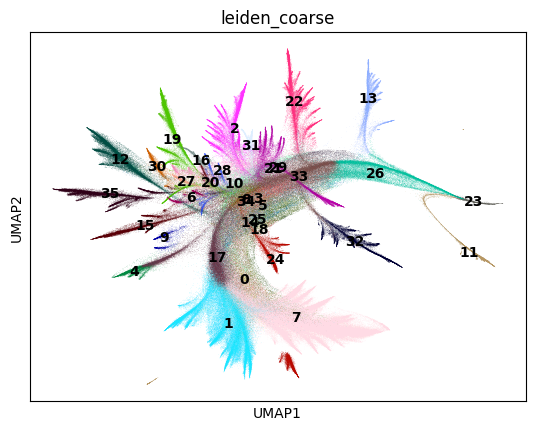

In [63]:
sc.pl.umap(adata_peaks, color="leiden_coarse", legend_loc="on data")

In [64]:
df = pd.DataFrame(index=adata_peaks.obs_names)
df["celltype"] = adata_peaks.obs["celltype"]
df["timepoint"] = adata_peaks.obs["timepoint"]
df["peak_type"] = adata_peaks.obs["peak_type_argelaguet"]
df["chromosome"] = adata_peaks.obs["chrom"]
df["leiden_coarse"] = adata_peaks.obs["leiden_coarse"]
df["leiden_fine"] = adata_peaks.obs["leiden_unified"]

In [69]:
df

,celltype,timepoint,peak_type,chromosome,leiden_coarse,leiden_fine
1-32-526,neural_posterior,10somites,intergenic,1,7,7_10
1-2372-3057,neural_optic,10somites,intergenic,1,12,12_10
1-3427-4032,primordial_germ_cells,10somites,intergenic,1,33,33_3
1-4469-7268,optic_cup,10somites,exonic,1,26,26_9
1-9541-9969,PSM,10somites,exonic,1,33,33_6
...,...,...,...,...,...,...
25-37496420-37496948,hatching_gland,5somites,exonic,25,18,18_2
25-37497049-37497789,muscle,20somites,intronic,25,15,15_9
25-37498106-37500090,neural,5somites,intronic,25,33,33_6
25-37500598-37500859,primordial_germ_cells,15somites,intronic,25,9,9_1


In [67]:
df.chromosome.unique()

['1', '2', '3', '4', '5', ..., '21', '22', '23', '24', '25']
Length: 25
Categories (25, object): ['1', '2', '3', '4', ..., '22', '23', '24', '25']

In [57]:
adata_peaks.obs["chrom"].values

['1', '1', '1', '1', '1', ..., '25', '25', '25', '25', '25']
Length: 640830
Categories (25, object): ['1', '2', '3', '4', ..., '22', '23', '24', '25']

In [55]:
adata_peaks.obs["chrom"].unique()

['1', '2', '3', '4', '5', ..., '21', '22', '23', '24', '25']
Length: 25
Categories (25, object): ['1', '2', '3', '4', ..., '22', '23', '24', '25']

In [54]:
df["chromosome"].unique()

['1', '2', '3', '4']
Categories (25, object): ['1', '2', '3', '4', ..., '22', '23', '24', '25']

In [70]:
df.to_csv("peak_umap_3d_annotated_v3.csv")